In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

folder = r"C:\Users\Harshit\project data"

print(os.listdir(folder))

['.ipynb_checkpoints', 'begin_inventory.csv', 'brand_performance.csv', 'end_inventory.csv', 'purchases.csv', 'purchase_prices.csv', 'sales.csv', 'vendor_invoice.csv', 'vendor_performance.db', 'vendor_performance_analysis.ipynb', 'vendor_performance_final.csv']


In [4]:
!pip install sqlalchemy


In [5]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [6]:
folder = r"C:\Users\Harshit\project data"

print(os.listdir(folder))

['.ipynb_checkpoints', 'begin_inventory.csv', 'brand_performance.csv', 'end_inventory.csv', 'purchases.csv', 'purchase_prices.csv', 'sales.csv', 'vendor_invoice.csv', 'vendor_performance.db', 'vendor_performance_analysis.ipynb', 'vendor_performance_final.csv']


In [7]:
begin_inventory = pd.read_csv(os.path.join(folder, "begin_inventory.csv"))
end_inventory = pd.read_csv(os.path.join(folder, "end_inventory.csv"))
purchases = pd.read_csv(os.path.join(folder, "purchases.csv"))
purchase_prices = pd.read_csv(os.path.join(folder, "purchase_prices.csv"))
sales = pd.read_csv(os.path.join(folder, "sales.csv"))
vendor_invoice = pd.read_csv(os.path.join(folder, "vendor_invoice.csv"))

print("All 6 datasets loaded successfully!")

All 6 datasets loaded successfully!


In [8]:
datasets = {
    "Begin Inventory": begin_inventory,
    "End Inventory": end_inventory,
    "Purchases": purchases,
    "Purchase Prices": purchase_prices,
    "Sales": sales,
    "Vendor Invoice": vendor_invoice
}

for name, df in datasets.items():
    print(f"\n{name}")
    print("Rows, Columns:", df.shape)
    print("Columns:", list(df.columns))


Begin Inventory
Rows, Columns: (206529, 9)
Columns: ['InventoryId', 'Store', 'City', 'Brand', 'Description', 'Size', 'onHand', 'Price', 'startDate']

End Inventory
Rows, Columns: (224489, 9)
Columns: ['InventoryId', 'Store', 'City', 'Brand', 'Description', 'Size', 'onHand', 'Price', 'endDate']

Purchases
Rows, Columns: (2372474, 16)
Columns: ['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'VendorNumber', 'VendorName', 'PONumber', 'PODate', 'ReceivingDate', 'InvoiceDate', 'PayDate', 'PurchasePrice', 'Quantity', 'Dollars', 'Classification']

Purchase Prices
Rows, Columns: (12261, 9)
Columns: ['Brand', 'Description', 'Price', 'Size', 'Volume', 'Classification', 'PurchasePrice', 'VendorNumber', 'VendorName']

Sales
Rows, Columns: (12825363, 14)
Columns: ['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'SalesQuantity', 'SalesDollars', 'SalesPrice', 'SalesDate', 'Volume', 'Classification', 'ExciseTax', 'VendorNo', 'VendorName']

Vendor Invoice
Rows, Columns: (5543, 10)
Colu

In [9]:
for name, df in datasets.items():
    print(f"\n===== {name} =====")
    print(df.isnull().sum())
    


===== Begin Inventory =====
InventoryId    0
Store          0
City           0
Brand          0
Description    0
Size           0
onHand         0
Price          0
startDate      0
dtype: int64

===== End Inventory =====
InventoryId       0
Store             0
City           1284
Brand             0
Description       0
Size              0
onHand            0
Price             0
endDate           0
dtype: int64

===== Purchases =====
InventoryId       0
Store             0
Brand             0
Description       0
Size              3
VendorNumber      0
VendorName        0
PONumber          0
PODate            0
ReceivingDate     0
InvoiceDate       0
PayDate           0
PurchasePrice     0
Quantity          0
Dollars           0
Classification    0
dtype: int64

===== Purchase Prices =====
Brand             0
Description       1
Price             0
Size              1
Volume            1
Classification    0
PurchasePrice     0
VendorNumber      0
VendorName        0
dtype: int64

===== 

In [10]:
for name, df in datasets.items():
    print(f"\n===== {name} =====")
    print(df.dtypes)


===== Begin Inventory =====
InventoryId        str
Store            int64
City               str
Brand            int64
Description        str
Size               str
onHand           int64
Price          float64
startDate          str
dtype: object

===== End Inventory =====
InventoryId        str
Store            int64
City               str
Brand            int64
Description        str
Size               str
onHand           int64
Price          float64
endDate            str
dtype: object

===== Purchases =====
InventoryId           str
Store               int64
Brand               int64
Description           str
Size                  str
VendorNumber        int64
VendorName            str
PONumber            int64
PODate                str
ReceivingDate         str
InvoiceDate           str
PayDate               str
PurchasePrice     float64
Quantity            int64
Dollars           float64
Classification      int64
dtype: object

===== Purchase Prices =====
Brand               

In [11]:
for name, df in datasets.items():
    print(f"\n===== {name} =====")
    display(df.describe(include="all").T)


===== Begin Inventory =====


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InventoryId,206529,206529,1_HARDERSFIELD_58,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store,206529.0,NaN,NaN,NaN,42.122457,23.191393,1.0,22.0,42.0,64.0,79.0
City,206529,67,MOUNTMEND,14264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Brand,206529.0,NaN,NaN,NaN,13761.48232,13059.429355,58.0,3746.0,8010.0,22143.0,90090.0
Description,206529,7291,Jagermeister Liqueur,459,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,206529,41,750mL,144514,NaN,NaN,NaN,NaN,NaN,NaN,NaN
onHand,206529.0,NaN,NaN,NaN,20.429455,31.467342,0.0,7.0,12.0,21.0,1251.0
Price,206529.0,NaN,NaN,NaN,22.25391,70.178964,0.0,9.99,14.99,21.99,13999.9
startDate,206529,1,2024-01-01,206529,NaN,NaN,NaN,NaN,NaN,NaN,NaN



===== End Inventory =====


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InventoryId,224489,224489,1_HARDERSFIELD_58,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store,224489.0,NaN,NaN,NaN,43.50574,23.326415,1.0,23.0,44.0,66.0,81.0
City,223205,67,MOUNTMEND,18065,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Brand,224489.0,NaN,NaN,NaN,14356.370513,13118.467851,58.0,3798.0,8259.0,23965.0,90631.0
Description,224489,8732,Jagermeister Liqueur,462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,224489,47,750mL,158227,NaN,NaN,NaN,NaN,NaN,NaN,NaN
onHand,224489.0,NaN,NaN,NaN,21.763988,37.233576,0.0,7.0,12.0,22.0,3676.0
Price,224489.0,NaN,NaN,NaN,23.585583,79.202775,0.49,9.99,14.99,23.49,13999.9
endDate,224489,1,2024-12-31,224489,NaN,NaN,NaN,NaN,NaN,NaN,NaN



===== Purchases =====


...

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Brand,12261.0,NaN,NaN,NaN,17989.067123,12528.503464,58.0,5990.0,18788.0,25117.0,90631.0
Description,12260,11114,Bacardi Superior Rum,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,12261.0,NaN,NaN,NaN,38.64024,206.151172,0.0,10.99,15.99,29.99,13999.9
Size,12260,56,750mL,9823,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Volume,12260,33,750,9840,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Classification,12261.0,NaN,NaN,NaN,1.708996,0.454244,1.0,1.0,2.0,2.0,2.0
PurchasePrice,12261.0,NaN,NaN,NaN,26.48822,156.182948,0.0,6.89,10.65,20.13,11111.03
VendorNumber,12261.0,NaN,NaN,NaN,10814.861757,19007.682322,2.0,3960.0,7153.0,9552.0,173357.0
VendorName,12261,136,MARTIGNETTI COMPANIES,1631,NaN,NaN,NaN,NaN,NaN,NaN,NaN



===== Sales =====


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InventoryId,12825363,267552,68_SOLARIS_5270,344,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store,12825363.0,NaN,NaN,NaN,43.895719,23.539472,1.0,23.0,47.0,66.0,81.0
Brand,12825363.0,NaN,NaN,NaN,12154.603955,12368.428771,58.0,3663.0,6349.0,17954.0,90631.0
Description,12825363,10182,Jack Daniels No 7 Black,78603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,12825363,51,750mL,7374318,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SalesQuantity,12825363.0,NaN,NaN,NaN,2.566623,4.55181,1.0,1.0,1.0,2.0,1231.0
SalesDollars,12825363.0,NaN,NaN,NaN,35.247576,88.356889,0.0,10.99,18.99,34.99,26061.14
SalesPrice,12825363.0,NaN,NaN,NaN,15.690266,15.127278,0.0,8.99,12.99,18.99,5799.99
SalesDate,12825363,364,2024-12-23,83959,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Volume,12825363.0,NaN,NaN,NaN,939.438863,699.320179,50.0,750.0,750.0,1000.0,20000.0



===== Vendor Invoice =====


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
VendorNumber,5543.0,NaN,NaN,NaN,20662.75212,34582.15841,2.0,3089.0,7240.0,10754.0,201359.0
VendorName,5543,129,AMERICAN VINTAGE BEVERAGE,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InvoiceDate,5543,373,2024-07-04,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PONumber,5543.0,NaN,NaN,NaN,10889.419087,1600.859969,8106.0,9503.5,10890.0,12275.5,13661.0
PODate,5543,319,2024-06-25,86,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PayDate,5543,382,2024-08-14,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,5543.0,NaN,NaN,NaN,6058.880931,14453.338164,1.0,83.0,423.0,5100.5,141660.0
Dollars,5543.0,NaN,NaN,NaN,58073.383642,140234.031377,4.14,967.81,4765.45,44587.175,1660435.88
Freight,5543.0,NaN,NaN,NaN,295.954301,713.585093,0.02,5.02,24.73,229.66,8468.22
Approval,374,1,Frank Delahunt,374,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# Convert date columns to datetime

begin_inventory["startDate"] = pd.to_datetime(
    begin_inventory["startDate"], errors="coerce"
)

end_inventory["endDate"] = pd.to_datetime(
    end_inventory["endDate"], errors="coerce"
)

purchases["PODate"] = pd.to_datetime(
    purchases["PODate"], errors="coerce"
)

purchases["ReceivingDate"] = pd.to_datetime(
    purchases["ReceivingDate"], errors="coerce"
)

purchases["InvoiceDate"] = pd.to_datetime(
    purchases["InvoiceDate"], errors="coerce"
)

purchases["PayDate"] = pd.to_datetime(
    purchases["PayDate"], errors="coerce"
)

sales["SalesDate"] = pd.to_datetime(
    sales["SalesDate"], errors="coerce"
)

vendor_invoice["InvoiceDate"] = pd.to_datetime(
    vendor_invoice["InvoiceDate"], errors="coerce"
)

vendor_invoice["PODate"] = pd.to_datetime(
    vendor_invoice["PODate"], errors="coerce"
)

vendor_invoice["PayDate"] = pd.to_datetime(
    vendor_invoice["PayDate"], errors="coerce"
)

print("Date columns converted successfully!")

Date columns converted successfully!


In [13]:
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")

Begin Inventory: 0 duplicate rows
End Inventory: 0 duplicate rows
Purchases: 0 duplicate rows
Purchase Prices: 0 duplicate rows
Sales: 0 duplicate rows
Vendor Invoice: 0 duplicate rows


In [14]:
print("Purchases:")
display(purchases[["PurchasePrice", "Quantity", "Dollars"]].describe())

print("Sales:")
display(sales[["SalesQuantity", "SalesDollars", "SalesPrice"]].describe())

print("Vendor Invoice:")
display(vendor_invoice[["Quantity", "Dollars", "Freight"]].describe())

Purchases:


,PurchasePrice,Quantity,Dollars
count,2.372474e+06,2.372474e+06,2.372474e+06
mean,1.205005e+01,1.415585e+01,1.356815e+02
std,1.794510e+01,2.344616e+01,2.816649e+02
min,0.000000e+00,1.000000e+00,0.000000e+00
25%,6.120000e+00,6.000000e+00,4.926000e+01
50%,9.220000e+00,1.000000e+01,8.393000e+01
75%,1.449000e+01,1.200000e+01,1.405200e+02
max,5.681810e+03,3.816000e+03,5.017570e+04


Sales:


,SalesQuantity,SalesDollars,SalesPrice
count,1.282536e+07,1.282536e+07,1.282536e+07
mean,2.566623e+00,3.524758e+01,1.569027e+01
std,4.551810e+00,8.835689e+01,1.512728e+01
min,1.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,1.099000e+01,8.990000e+00
50%,1.000000e+00,1.899000e+01,1.299000e+01
75%,2.000000e+00,3.499000e+01,1.899000e+01
max,1.231000e+03,2.606114e+04,5.799990e+03


Vendor Invoice:


,Quantity,Dollars,Freight
count,5543.000000,5.543000e+03,5543.000000
mean,6058.880931,5.807338e+04,295.954301
std,14453.338164,1.402340e+05,713.585093
min,1.000000,4.140000e+00,0.020000
25%,83.000000,9.678100e+02,5.020000
50%,423.000000,4.765450e+03,24.730000
75%,5100.500000,4.458718e+04,229.660000
max,141660.000000,1.660436e+06,8468.220000


In [15]:
print("Total Purchase Dollars:",
      purchases["Dollars"].sum())

print("Total Sales Dollars:",
      sales["SalesDollars"].sum())

print("Total Sales Quantity:",
      sales["SalesQuantity"].sum())

print("Total Purchase Quantity:",
      purchases["Quantity"].sum())

print("Total Freight:",
      vendor_invoice["Freight"].sum())

Total Purchase Dollars: 321900765.53
Total Sales Dollars: 452062952.02000004
Total Sales Quantity: 32917876
Total Purchase Quantity: 33584377
Total Freight: 1640474.6900000002


In [16]:
# Look at unique vendors
print("Number of unique vendors in purchases:",
      purchases["VendorNumber"].nunique())

print("Number of unique vendors in sales:",
      sales["VendorNo"].nunique())

# Top vendors by purchase dollars
top_vendors = (
    purchases.groupby("VendorNumber")["Dollars"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 vendors by purchase value:")
display(top_vendors)


Number of unique vendors in purchases: 126
Number of unique vendors in sales: 127

Top 10 vendors by purchase value:


VendorNumber
3960     50959796.85
4425     27861690.02
12546    24203151.05
17035    24124091.56
480      17624378.72
1392     15573917.90
1128     13529433.08
9165     13210613.93
3252     12289608.09
9552     10935817.30
Name: Dollars, dtype: float64

In [17]:
vendor_sales = (
    sales.groupby("VendorNo")
    .agg(
        TotalSales=("SalesDollars", "sum"),
        TotalQuantity=("SalesQuantity", "sum")
    )
    .reset_index()
)

vendor_sales.head()

,VendorNo,TotalSales,TotalQuantity
0,2,1265.58,42
1,60,67576.22,3978
2,105,15748.75,325
3,200,1719.97,103
4,287,1616.92,108


In [18]:
vendor_purchases = (
    purchases.groupby("VendorNumber")
    .agg(
        TotalPurchases=("Dollars", "sum"),
        PurchaseQuantity=("Quantity", "sum")
    )
    .reset_index()
)

vendor_purchases.head()

,VendorNumber,TotalPurchases,PurchaseQuantity
0,2,5630.88,328
1,54,105.07,1
2,60,76770.25,4732
3,105,11706.20,332
4,200,1205.16,132


In [19]:
vendor_sales = vendor_sales.rename(
    columns={"VendorNo": "VendorNumber"}
)

In [20]:
vendor_performance = pd.merge(
    vendor_purchases,
    vendor_sales,
    on="VendorNumber",
    how="outer"
)

vendor_performance.head()

,VendorNumber,TotalPurchases,PurchaseQuantity,TotalSales,TotalQuantity
0,2,5630.88,328.0,1265.58,42.0
1,54,105.07,1.0,NaN,NaN
2,60,76770.25,4732.0,67576.22,3978.0
3,105,11706.20,332.0,15748.75,325.0
4,200,1205.16,132.0,1719.97,103.0


In [21]:
vendor_performance[
    ["TotalPurchases", "PurchaseQuantity", "TotalSales", "TotalQuantity"]
] = vendor_performance[
    ["TotalPurchases", "PurchaseQuantity", "TotalSales", "TotalQuantity"]
].fillna(0)

vendor_performance.head()

,VendorNumber,TotalPurchases,PurchaseQuantity,TotalSales,TotalQuantity
0,2,5630.88,328.0,1265.58,42.0
1,54,105.07,1.0,0.00,0.0
2,60,76770.25,4732.0,67576.22,3978.0
3,105,11706.20,332.0,15748.75,325.0
4,200,1205.16,132.0,1719.97,103.0


In [22]:
vendor_performance["GrossProfit"] = (
    vendor_performance["TotalSales"]
    - vendor_performance["TotalPurchases"]
)

In [23]:
vendor_performance["ProfitMargin"] = (
    vendor_performance["GrossProfit"]
    / vendor_performance["TotalSales"]
) * 100

In [24]:
vendor_performance["ProfitMargin"] = (
    vendor_performance["ProfitMargin"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

In [25]:
vendor_performance.sort_values(
    "GrossProfit",
    ascending=False
).head(10)

,VendorNumber,TotalPurchases,PurchaseQuantity,TotalSales,TotalQuantity,GrossProfit,ProfitMargin
41,3960,50959796.85,5459788.0,68742416.99,5422703.0,17782620.14,25.868483
43,4425,27861690.02,2640411.0,41047306.30,2581318.0,13185616.28,32.122976
17,1392,15573917.90,2325892.0,24469172.93,2301688.0,8895255.03,36.352904
101,17035,24124091.56,1647558.0,32281247.95,1613460.0,8157156.39,25.269024
97,12546,24203151.05,2737165.0,31906320.54,2630226.0,7703169.49,24.143083
7,480,17624378.72,1427075.0,25014556.89,1457301.0,7390178.17,29.543510
35,3252,12289608.09,1858260.0,18556085.61,1809023.0,6266477.52,33.770471
13,1128,13529433.08,1006122.0,18478557.47,983853.0,4949124.39,26.783067
81,9165,13210613.93,1077527.0,17822938.45,1043235.0,4612324.52,25.878586
84,9552,10935817.30,1372841.0,15465247.75,1343481.0,4529430.45,29.287798


In [26]:
print("Top 10 vendors by Gross Profit:")
display(
    vendor_performance
    .sort_values("GrossProfit", ascending=False)
    .head(10)
)

print("Bottom 10 vendors by Gross Profit:")
display(
    vendor_performance
    .sort_values("GrossProfit", ascending=True)
    .head(10)
)

Top 10 vendors by Gross Profit:


,VendorNumber,TotalPurchases,PurchaseQuantity,TotalSales,TotalQuantity,GrossProfit,ProfitMargin
41,3960,50959796.85,5459788.0,68742416.99,5422703.0,17782620.14,25.868483
43,4425,27861690.02,2640411.0,41047306.30,2581318.0,13185616.28,32.122976
17,1392,15573917.90,2325892.0,24469172.93,2301688.0,8895255.03,36.352904
101,17035,24124091.56,1647558.0,32281247.95,1613460.0,8157156.39,25.269024
97,12546,24203151.05,2737165.0,31906320.54,2630226.0,7703169.49,24.143083
7,480,17624378.72,1427075.0,25014556.89,1457301.0,7390178.17,29.543510
35,3252,12289608.09,1858260.0,18556085.61,1809023.0,6266477.52,33.770471
13,1128,13529433.08,1006122.0,18478557.47,983853.0,4949124.39,26.783067
81,9165,13210613.93,1077527.0,17822938.45,1043235.0,4612324.52,25.878586
84,9552,10935817.30,1372841.0,15465247.75,1343481.0,4529430.45,29.287798


Bottom 10 vendors by Gross Profit:


,VendorNumber,TotalPurchases,PurchaseQuantity,TotalSales,TotalQuantity,GrossProfit,ProfitMargin
2,60,76770.25,4732.0,67576.22,3978.0,-9194.03,-13.605422
123,90059,14465.06,919.0,6256.87,313.0,-8208.19,-131.186839
0,2,5630.88,328.0,1265.58,42.0,-4365.30,-344.924857
40,3951,5500.32,372.0,1533.68,82.0,-3966.64,-258.635439
57,6280,2966.31,243.0,1124.38,62.0,-1841.93,-163.817393
36,3551,5393.04,516.0,3837.60,240.0,-1555.44,-40.531582
50,5083,2320.80,240.0,1111.26,74.0,-1209.54,-108.844015
127,173357,41036.44,1990.0,40021.12,1488.0,-1015.32,-2.536960
5,287,2399.70,230.0,1616.92,108.0,-782.78,-48.411795
125,99166,25961.04,1212.0,25371.54,846.0,-589.50,-2.323470


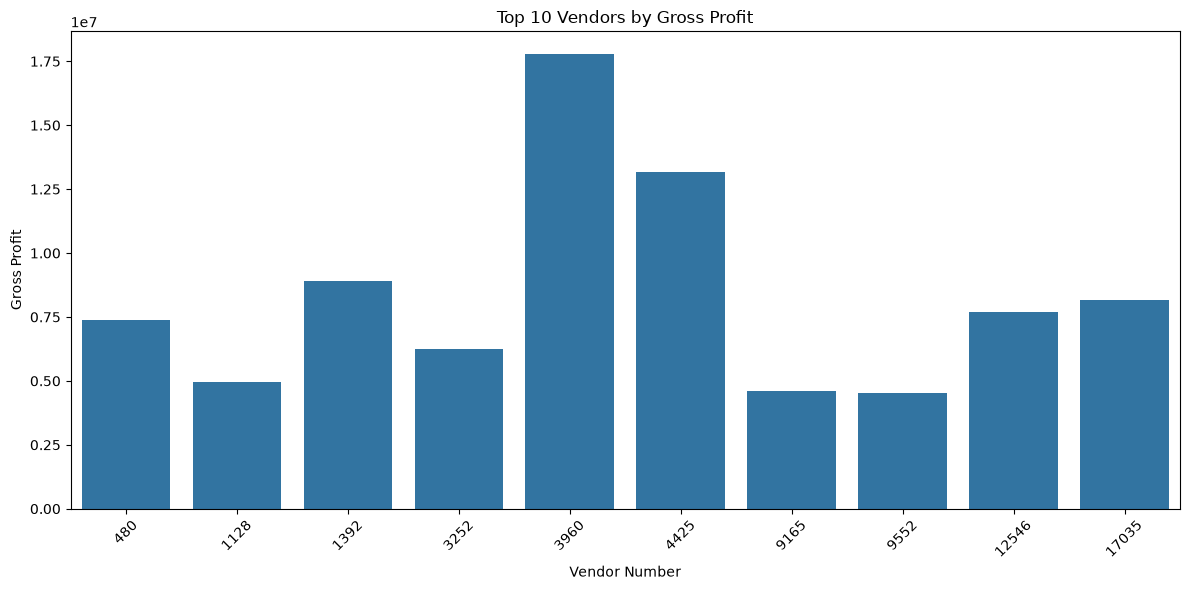

In [27]:
top_10_profit = (
    vendor_performance
    .sort_values("GrossProfit", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10_profit,
    x="VendorNumber",
    y="GrossProfit"
)

plt.title("Top 10 Vendors by Gross Profit")
plt.xlabel("Vendor Number")
plt.ylabel("Gross Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
print("Begin Inventory columns:")
print(begin_inventory.columns.tolist())

print("\nEnd Inventory columns:")
print(end_inventory.columns.tolist())

Begin Inventory columns:
['InventoryId', 'Store', 'City', 'Brand', 'Description', 'Size', 'onHand', 'Price', 'startDate']

End Inventory columns:
['InventoryId', 'Store', 'City', 'Brand', 'Description', 'Size', 'onHand', 'Price', 'endDate']


In [29]:
print("BEGIN INVENTORY:")
print(begin_inventory.columns.tolist())

print("\nEND INVENTORY:")
print(end_inventory.columns.tolist())

BEGIN INVENTORY:
['InventoryId', 'Store', 'City', 'Brand', 'Description', 'Size', 'onHand', 'Price', 'startDate']

END INVENTORY:
['InventoryId', 'Store', 'City', 'Brand', 'Description', 'Size', 'onHand', 'Price', 'endDate']


In [30]:
print(begin_inventory[["InventoryId", "Brand", "Description", "onHand", "Price"]].head(10))


          InventoryId  Brand                  Description  onHand  Price
0   1_HARDERSFIELD_58     58  Gekkeikan Black & Gold Sake       8  12.99
1   1_HARDERSFIELD_60     60       Canadian Club 1858 VAP       7  10.99
2   1_HARDERSFIELD_62     62     Herradura Silver Tequila       6  36.99
3   1_HARDERSFIELD_63     63   Herradura Reposado Tequila       3  38.99
4   1_HARDERSFIELD_72     72         No. 3 London Dry Gin       6  34.99
5   1_HARDERSFIELD_75     75    Three Olives Tomato Vodka      18  14.99
6   1_HARDERSFIELD_77     77  Three Olives Espresso Vodka       7  14.99
7   1_HARDERSFIELD_79     79     Three Olives Loopy Vodka       2  14.99
8  1_HARDERSFIELD_115    115              Belvedere Vodka       5  27.99
9  1_HARDERSFIELD_120    120  Tarantula Azul Tequila Gift      11  13.99


In [31]:
print(purchases[["VendorNumber", "Brand", "Description", "Quantity", "Dollars"]].head(10))

   VendorNumber  Brand                   Description  Quantity  Dollars
0           105   8412     Tequila Ocho Plata Fresno         6   214.26
1          4466   5255  TGI Fridays Ultimte Mudslide         4    37.40
2          4466   5215  TGI Fridays Long Island Iced         5    47.05
3          4466   5255  TGI Fridays Ultimte Mudslide         6    56.10
4           388   2034     Glendalough Double Barrel         5   106.60
5           480   3348           Bombay Sapphire Gin         6   134.28
6           480   8358             Bacardi 151 Proof        12   173.88
7           480   4903          Bacardi Superior Rum        48   137.76
8           480   3782    Grey Goose Le Citron Vodka         5    94.45
9           480   4233     Castillo Silver Label Rum        23   181.01


In [32]:
print(sales[["VendorNo", "Brand", "Description", "SalesQuantity", "SalesDollars"]].head(10))

   VendorNo  Brand                  Description  SalesQuantity  SalesDollars
0     12546   1004   Jim Beam w/2 Rocks Glasses              1         16.49
1     12546   1004   Jim Beam w/2 Rocks Glasses              2         32.98
2     12546   1004   Jim Beam w/2 Rocks Glasses              1         16.49
3     12546   1004   Jim Beam w/2 Rocks Glasses              1         14.49
4     12546   1005      Maker's Mark Combo Pack              2         69.98
5     12546   1005      Maker's Mark Combo Pack              1         34.99
6     12546   1005      Maker's Mark Combo Pack              1         34.99
7     12546   1005      Maker's Mark Combo Pack              1         34.99
8      2000  10058  F Coppola Dmd Ivry Cab Svgn              4         59.96
9      2000  10058  F Coppola Dmd Ivry Cab Svgn              1         14.99


In [33]:
print("Inventory IDs:", begin_inventory["InventoryId"].nunique())
print("Purchase brands:", purchases["Brand"].nunique())
print("Sales brands:", sales["Brand"].nunique())

Inventory IDs: 206529
Purchase brands: 10664
Sales brands: 11237


In [34]:
print("Sample Inventory IDs:")
display(begin_inventory["InventoryId"].head(20))

print("\nSample Purchase IDs:")
display(purchases["InventoryId"].head(20))

print("\nSample Sales IDs:")
display(sales["InventoryId"].head(20))

Sample Inventory IDs:


0      1_HARDERSFIELD_58
1      1_HARDERSFIELD_60
2      1_HARDERSFIELD_62
3      1_HARDERSFIELD_63
4      1_HARDERSFIELD_72
5      1_HARDERSFIELD_75
6      1_HARDERSFIELD_77
7      1_HARDERSFIELD_79
8     1_HARDERSFIELD_115
9     1_HARDERSFIELD_120
10    1_HARDERSFIELD_126
11    1_HARDERSFIELD_165
12    1_HARDERSFIELD_171
13    1_HARDERSFIELD_175
14    1_HARDERSFIELD_178
15    1_HARDERSFIELD_192
16    1_HARDERSFIELD_211
17    1_HARDERSFIELD_233
18    1_HARDERSFIELD_247
19    1_HARDERSFIELD_254
Name: InventoryId, dtype: str


Sample Purchase IDs:


0       69_MOUNTMEND_8412
1        30_CULCHETH_5255
2       34_PITMERDEN_5215
3     1_HARDERSFIELD_5255
4       76_DONCASTER_2034
5           5_SUTTON_3348
6     1_HARDERSFIELD_8358
7        30_CULCHETH_4903
8       34_PITMERDEN_3782
9     1_HARDERSFIELD_4233
10    1_HARDERSFIELD_3830
11      78_EASTHAVEN_2628
12       30_CULCHETH_4196
13      22_SHARNWICK_3830
14      38_GOULCREST_8358
15     67_EANVERNESS_3961
16      22_SHARNWICK_3139
17      78_EASTHAVEN_3016
18      69_MOUNTMEND_7221
19      69_MOUNTMEND_3782
Name: InventoryId, dtype: str


Sample Sales IDs:


0      1_HARDERSFIELD_1004
1      1_HARDERSFIELD_1004
2      1_HARDERSFIELD_1004
3      1_HARDERSFIELD_1004
4      1_HARDERSFIELD_1005
5      1_HARDERSFIELD_1005
6      1_HARDERSFIELD_1005
7      1_HARDERSFIELD_1005
8     1_HARDERSFIELD_10058
9     1_HARDERSFIELD_10058
10    1_HARDERSFIELD_10058
11    1_HARDERSFIELD_10058
12    1_HARDERSFIELD_10058
13    1_HARDERSFIELD_10058
14    1_HARDERSFIELD_10058
15    1_HARDERSFIELD_10058
16    1_HARDERSFIELD_10058
17     1_HARDERSFIELD_1006
18    1_HARDERSFIELD_10062
19    1_HARDERSFIELD_10062
Name: InventoryId, dtype: str

In [35]:
# Check how InventoryId appears across the datasets

print("Inventory IDs in Begin Inventory:")
print(begin_inventory["InventoryId"].head(10).tolist())

print("\nInventory IDs in Purchases:")
print(purchases["InventoryId"].head(10).tolist())

print("\nInventory IDs in Sales:")
print(sales["InventoryId"].head(10).tolist())

Inventory IDs in Begin Inventory:
['1_HARDERSFIELD_58', '1_HARDERSFIELD_60', '1_HARDERSFIELD_62', '1_HARDERSFIELD_63', '1_HARDERSFIELD_72', '1_HARDERSFIELD_75', '1_HARDERSFIELD_77', '1_HARDERSFIELD_79', '1_HARDERSFIELD_115', '1_HARDERSFIELD_120']

Inventory IDs in Purchases:
['69_MOUNTMEND_8412', '30_CULCHETH_5255', '34_PITMERDEN_5215', '1_HARDERSFIELD_5255', '76_DONCASTER_2034', '5_SUTTON_3348', '1_HARDERSFIELD_8358', '30_CULCHETH_4903', '34_PITMERDEN_3782', '1_HARDERSFIELD_4233']

Inventory IDs in Sales:
['1_HARDERSFIELD_1004', '1_HARDERSFIELD_1004', '1_HARDERSFIELD_1004', '1_HARDERSFIELD_1004', '1_HARDERSFIELD_1005', '1_HARDERSFIELD_1005', '1_HARDERSFIELD_1005', '1_HARDERSFIELD_1005', '1_HARDERSFIELD_10058', '1_HARDERSFIELD_10058']


In [36]:
# Check whether InventoryId uniquely identifies a product

print(
    "Duplicate InventoryId rows in begin inventory:",
    begin_inventory["InventoryId"].duplicated().sum()
)

print(
    "Duplicate InventoryId rows in purchases:",
    purchases["InventoryId"].duplicated().sum()
)

print(
    "Duplicate InventoryId rows in sales:",
    sales["InventoryId"].duplicated().sum()
)

Duplicate InventoryId rows in begin inventory: 0
Duplicate InventoryId rows in purchases: 2126567
Duplicate InventoryId rows in sales: 12557811


In [37]:
vendor_product = (
    purchases[
        ["VendorNumber", "Brand", "Description", "InventoryId"]
    ]
    .drop_duplicates()
)

print("Vendor-product mappings:", len(vendor_product))

display(vendor_product.head(20))

Vendor-product mappings: 246676


,VendorNumber,Brand,Description,InventoryId
0,105,8412,Tequila Ocho Plata Fresno,69_MOUNTMEND_8412
1,4466,5255,TGI Fridays Ultimte Mudslide,30_CULCHETH_5255
2,4466,5215,TGI Fridays Long Island Iced,34_PITMERDEN_5215
3,4466,5255,TGI Fridays Ultimte Mudslide,1_HARDERSFIELD_5255
4,388,2034,Glendalough Double Barrel,76_DONCASTER_2034
5,480,3348,Bombay Sapphire Gin,5_SUTTON_3348
6,480,8358,Bacardi 151 Proof,1_HARDERSFIELD_8358
7,480,4903,Bacardi Superior Rum,30_CULCHETH_4903
8,480,3782,Grey Goose Le Citron Vodka,34_PITMERDEN_3782
9,480,4233,Castillo Silver Label Rum,1_HARDERSFIELD_4233


In [38]:
# Number of products associated with each vendor

vendor_product_count = (
    vendor_product
    .groupby("VendorNumber")["InventoryId"]
    .nunique()
    .sort_values(ascending=False)
)

display(vendor_product_count.head(20))

VendorNumber
4425     24599
3960     18024
12546    16033
9165     15896
1392     14515
3252     13824
9552     13622
17035     9538
10754     9536
480       7224
8004      6129
7153      5556
9815      5134
1128      5031
7245      4673
2000      4478
8112      3853
9819      3679
6785      3316
8673      3280
Name: InventoryId, dtype: int64

In [39]:
# Vendor purchase summary
vendor_purchases = (
    purchases.groupby("VendorNumber")
    .agg(
        TotalPurchases=("Dollars", "sum"),
        PurchaseQuantity=("Quantity", "sum")
    )
    .reset_index()
)

# Vendor sales summary
vendor_sales = (
    sales.groupby("VendorNo")
    .agg(
        TotalSales=("SalesDollars", "sum"),
        SalesQuantity=("SalesQuantity", "sum")
    )
    .reset_index()
)

# Make vendor column names consistent
vendor_sales = vendor_sales.rename(
    columns={"VendorNo": "VendorNumber"}
)

# Merge
vendor_performance = pd.merge(
    vendor_purchases,
    vendor_sales,
    on="VendorNumber",
    how="outer"
)

# Replace missing values
numeric_cols = [
    "TotalPurchases",
    "PurchaseQuantity",
    "TotalSales",
    "SalesQuantity"
]

vendor_performance[numeric_cols] = (
    vendor_performance[numeric_cols].fillna(0)
)

print("Vendor performance table created!")
display(vendor_performance.head())

Vendor performance table created!


,VendorNumber,TotalPurchases,PurchaseQuantity,TotalSales,SalesQuantity
0,2,5630.88,328.0,1265.58,42.0
1,54,105.07,1.0,0.00,0.0
2,60,76770.25,4732.0,67576.22,3978.0
3,105,11706.20,332.0,15748.75,325.0
4,200,1205.16,132.0,1719.97,103.0


In [40]:
vendor_performance["GrossProfit"] = (
    vendor_performance["TotalSales"]
    - vendor_performance["TotalPurchases"]
)

vendor_performance["ProfitMargin"] = np.where(
    vendor_performance["TotalSales"] > 0,
    (vendor_performance["GrossProfit"]
     / vendor_performance["TotalSales"]) * 100,
    0
)

display(
    vendor_performance.sort_values(
        "GrossProfit",
        ascending=False
    ).head(10)
)

,VendorNumber,TotalPurchases,PurchaseQuantity,TotalSales,SalesQuantity,GrossProfit,ProfitMargin
41,3960,50959796.85,5459788.0,68742416.99,5422703.0,17782620.14,25.868483
43,4425,27861690.02,2640411.0,41047306.30,2581318.0,13185616.28,32.122976
17,1392,15573917.90,2325892.0,24469172.93,2301688.0,8895255.03,36.352904
101,17035,24124091.56,1647558.0,32281247.95,1613460.0,8157156.39,25.269024
97,12546,24203151.05,2737165.0,31906320.54,2630226.0,7703169.49,24.143083
7,480,17624378.72,1427075.0,25014556.89,1457301.0,7390178.17,29.543510
35,3252,12289608.09,1858260.0,18556085.61,1809023.0,6266477.52,33.770471
13,1128,13529433.08,1006122.0,18478557.47,983853.0,4949124.39,26.783067
81,9165,13210613.93,1077527.0,17822938.45,1043235.0,4612324.52,25.878586
84,9552,10935817.30,1372841.0,15465247.75,1343481.0,4529430.45,29.287798


In [41]:
print("TOP 10 VENDORS BY SALES")
display(
    vendor_performance
    .sort_values("TotalSales", ascending=False)
    .head(10)
)

print("TOP 10 VENDORS BY PROFIT")
display(
    vendor_performance
    .sort_values("GrossProfit", ascending=False)
    .head(10)
)

print("LOWEST 10 VENDORS BY PROFIT")
display(
    vendor_performance
    .sort_values("GrossProfit", ascending=True)
    .head(10)
)

TOP 10 VENDORS BY SALES


,VendorNumber,TotalPurchases,PurchaseQuantity,TotalSales,SalesQuantity,GrossProfit,ProfitMargin
41,3960,50959796.85,5459788.0,68742416.99,5422703.0,17782620.14,25.868483
43,4425,27861690.02,2640411.0,41047306.30,2581318.0,13185616.28,32.122976
101,17035,24124091.56,1647558.0,32281247.95,1613460.0,8157156.39,25.269024
97,12546,24203151.05,2737165.0,31906320.54,2630226.0,7703169.49,24.143083
7,480,17624378.72,1427075.0,25014556.89,1457301.0,7390178.17,29.543510
17,1392,15573917.90,2325892.0,24469172.93,2301688.0,8895255.03,36.352904
35,3252,12289608.09,1858260.0,18556085.61,1809023.0,6266477.52,33.770471
13,1128,13529433.08,1006122.0,18478557.47,983853.0,4949124.39,26.783067
81,9165,13210613.93,1077527.0,17822938.45,1043235.0,4612324.52,25.878586
84,9552,10935817.30,1372841.0,15465247.75,1343481.0,4529430.45,29.287798


TOP 10 VENDORS BY PROFIT


,VendorNumber,TotalPurchases,PurchaseQuantity,TotalSales,SalesQuantity,GrossProfit,ProfitMargin
41,3960,50959796.85,5459788.0,68742416.99,5422703.0,17782620.14,25.868483
43,4425,27861690.02,2640411.0,41047306.30,2581318.0,13185616.28,32.122976
17,1392,15573917.90,2325892.0,24469172.93,2301688.0,8895255.03,36.352904
101,17035,24124091.56,1647558.0,32281247.95,1613460.0,8157156.39,25.269024
97,12546,24203151.05,2737165.0,31906320.54,2630226.0,7703169.49,24.143083
7,480,17624378.72,1427075.0,25014556.89,1457301.0,7390178.17,29.543510
35,3252,12289608.09,1858260.0,18556085.61,1809023.0,6266477.52,33.770471
13,1128,13529433.08,1006122.0,18478557.47,983853.0,4949124.39,26.783067
81,9165,13210613.93,1077527.0,17822938.45,1043235.0,4612324.52,25.878586
84,9552,10935817.30,1372841.0,15465247.75,1343481.0,4529430.45,29.287798


LOWEST 10 VENDORS BY PROFIT


,VendorNumber,TotalPurchases,PurchaseQuantity,TotalSales,SalesQuantity,GrossProfit,ProfitMargin
2,60,76770.25,4732.0,67576.22,3978.0,-9194.03,-13.605422
123,90059,14465.06,919.0,6256.87,313.0,-8208.19,-131.186839
0,2,5630.88,328.0,1265.58,42.0,-4365.30,-344.924857
40,3951,5500.32,372.0,1533.68,82.0,-3966.64,-258.635439
57,6280,2966.31,243.0,1124.38,62.0,-1841.93,-163.817393
36,3551,5393.04,516.0,3837.60,240.0,-1555.44,-40.531582
50,5083,2320.80,240.0,1111.26,74.0,-1209.54,-108.844015
127,173357,41036.44,1990.0,40021.12,1488.0,-1015.32,-2.536960
5,287,2399.70,230.0,1616.92,108.0,-782.78,-48.411795
125,99166,25961.04,1212.0,25371.54,846.0,-589.50,-2.323470


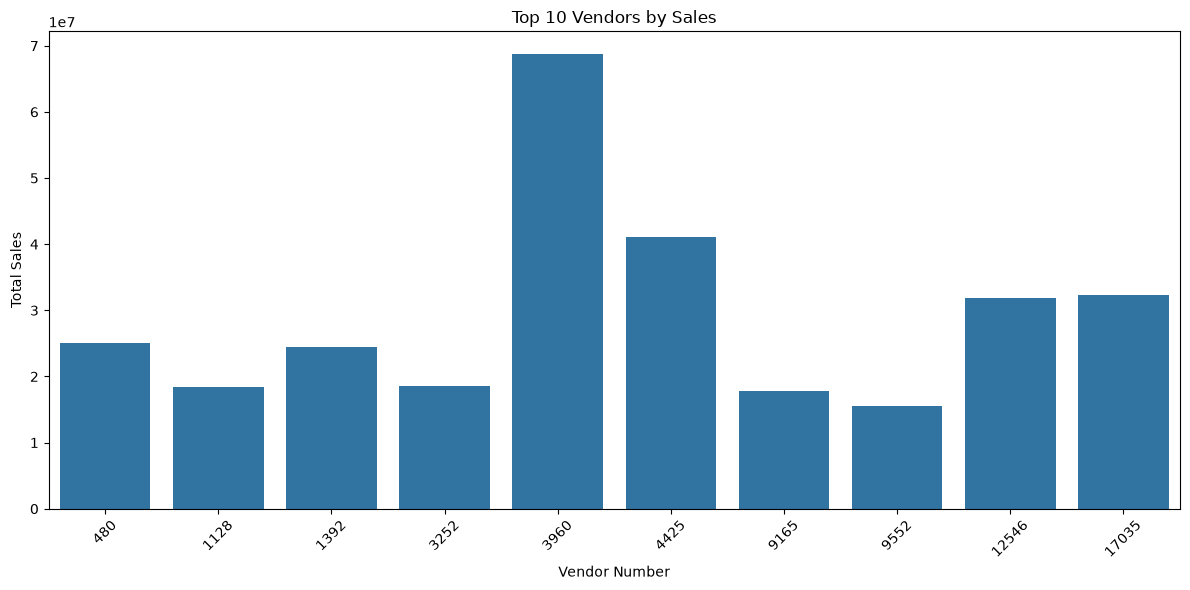

In [42]:
top_sales = (
    vendor_performance
    .sort_values("TotalSales", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_sales,
    x="VendorNumber",
    y="TotalSales"
)

plt.title("Top 10 Vendors by Sales")
plt.xlabel("Vendor Number")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

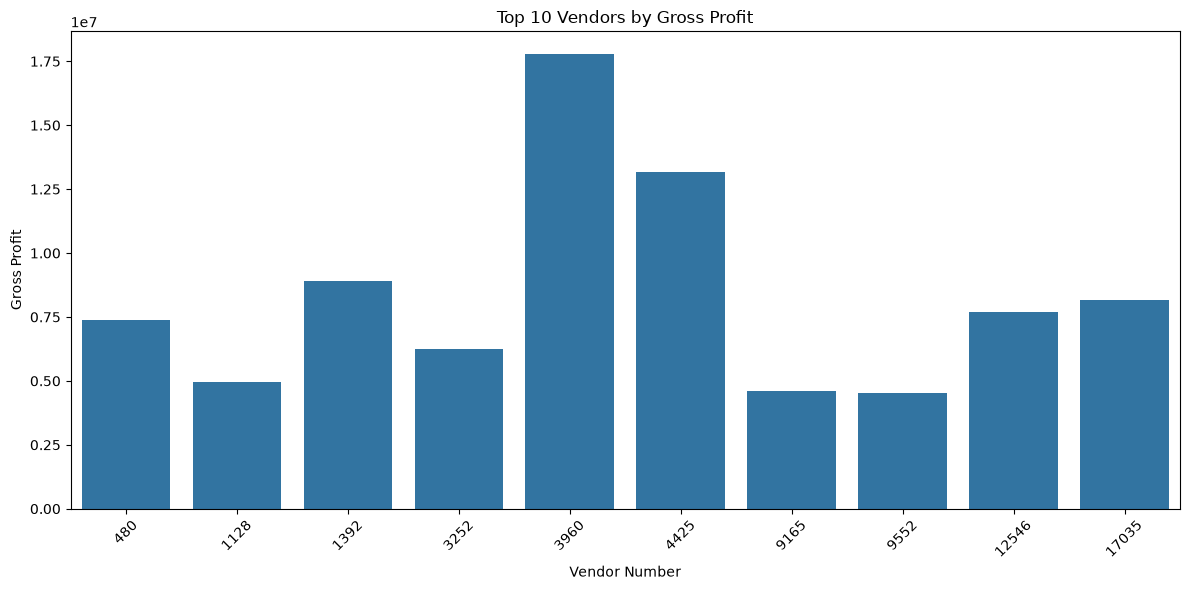

In [43]:
top_profit = (
    vendor_performance
    .sort_values("GrossProfit", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_profit,
    x="VendorNumber",
    y="GrossProfit"
)

plt.title("Top 10 Vendors by Gross Profit")
plt.xlabel("Vendor Number")
plt.ylabel("Gross Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

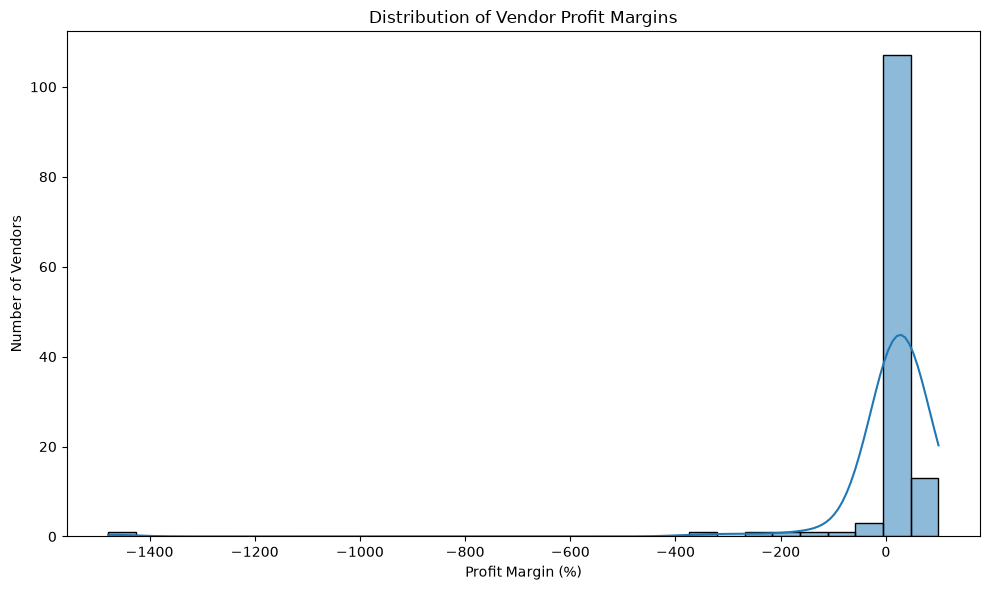

In [44]:
plt.figure(figsize=(10, 6))

sns.histplot(
    vendor_performance["ProfitMargin"],
    bins=30,
    kde=True
)

plt.title("Distribution of Vendor Profit Margins")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Number of Vendors")
plt.tight_layout()
plt.show()

In [45]:
brand_sales = (
    sales.groupby(["Brand", "Description"])
    .agg(
        TotalSales=("SalesDollars", "sum"),
        TotalQuantity=("SalesQuantity", "sum")
    )
    .reset_index()
)

display(
    brand_sales
    .sort_values("TotalSales", ascending=False)
    .head(10)
)

,Brand,Description,TotalSales,TotalQuantity
609,1233,Jack Daniels No 7 Black,5101919.51,142049
1715,3405,Tito's Handmade Vodka,4819073.49,160247
3302,8068,Absolut 80 Proof,4538120.60,187140
2232,4261,Capt Morgan Spiced Rum,4475972.88,200412
1802,3545,Ketel One Vodka,4223107.62,135838
2014,3858,Grey Goose Vodka,3383912.40,141860
1194,2589,Jameson Irish Whiskey,2773367.73,69627
1769,3489,Tanqueray,2640491.19,90481
1539,3102,Smirnoff Traveler,2592041.35,148265
672,1376,Jim Beam,2435393.39,107061


In [46]:
brand_purchases = (
    purchases.groupby(["Brand", "Description"])
    .agg(
        TotalPurchaseCost=("Dollars", "sum"),
        PurchaseQuantity=("Quantity", "sum")
    )
    .reset_index()
)

display(
    brand_purchases
    .sort_values("TotalPurchaseCost", ascending=False)
    .head(10)
)

,Brand,Description,TotalPurchaseCost,PurchaseQuantity
571,1233,Jack Daniels No 7 Black,3811251.60,145080
1629,3405,Tito's Handmade Vodka,3804041.22,164038
3159,8068,Absolut 80 Proof,3418303.68,187407
2122,4261,Capt Morgan Spiced Rum,3261197.94,201682
1710,3545,Ketel One Vodka,3023206.01,138109
1911,3858,Grey Goose Vodka,2466635.93,138809
1139,2589,Jameson Irish Whiskey,2177285.08,70783
1464,3102,Smirnoff Traveler,2088334.84,161386
1678,3489,Tanqueray,1903739.55,91835
631,1376,Jim Beam,1773427.14,108866


In [47]:
brand_performance = pd.merge(
    brand_sales,
    brand_purchases,
    on=["Brand", "Description"],
    how="outer"
)

brand_performance[
    ["TotalSales", "TotalQuantity",
     "TotalPurchaseCost", "PurchaseQuantity"]
] = brand_performance[
    ["TotalSales", "TotalQuantity",
     "TotalPurchaseCost", "PurchaseQuantity"]
].fillna(0)

brand_performance["GrossProfit"] = (
    brand_performance["TotalSales"]
    - brand_performance["TotalPurchaseCost"]
)

brand_performance["ProfitMargin"] = np.where(
    brand_performance["TotalSales"] > 0,
    brand_performance["GrossProfit"]
    / brand_performance["TotalSales"] * 100,
    0
)

display(
    brand_performance
    .sort_values("GrossProfit", ascending=False)
    .head(10)
)

,Brand,Description,TotalSales,TotalQuantity,TotalPurchaseCost,PurchaseQuantity,GrossProfit,ProfitMargin
616,1233,Jack Daniels No 7 Black,5101919.51,142049.0,3811251.60,145080.0,1290667.91,25.297693
2251,4261,Capt Morgan Spiced Rum,4475972.88,200412.0,3261197.94,201682.0,1214774.94,27.139908
1818,3545,Ketel One Vodka,4223107.62,135838.0,3023206.01,138109.0,1199901.61,28.412764
3326,8068,Absolut 80 Proof,4538120.60,187140.0,3418303.68,187407.0,1119816.92,24.675786
1731,3405,Tito's Handmade Vodka,4819073.49,160247.0,3804041.22,164038.0,1015032.27,21.062810
2030,3858,Grey Goose Vodka,3383912.40,141860.0,2466635.93,138809.0,917276.47,27.106980
3040,6570,Kendall Jackson Chard Vt RSV,2326007.78,214238.0,1460072.36,215668.0,865935.42,37.228397
1785,3489,Tanqueray,2640491.19,90481.0,1903739.55,91835.0,736751.64,27.902068
1260,2663,Dewars White Label,2189368.78,70122.0,1478001.42,69001.0,711367.36,32.491893
3335,8082,Baileys Irish Cream,2068091.16,65184.0,1396130.77,64249.0,671960.39,32.491817


In [48]:
high_sales_low_profit = (
    brand_performance[
        (brand_performance["TotalSales"] >
         brand_performance["TotalSales"].median())
        &
        (brand_performance["ProfitMargin"] <
         brand_performance["ProfitMargin"].median())
    ]
    .sort_values("TotalSales", ascending=False)
)

display(high_sales_low_profit.head(20))

,Brand,Description,TotalSales,TotalQuantity,TotalPurchaseCost,PurchaseQuantity,GrossProfit,ProfitMargin
616,1233,Jack Daniels No 7 Black,5101919.51,142049.0,3811251.60,145080.0,1290667.91,25.297693
1731,3405,Tito's Handmade Vodka,4819073.49,160247.0,3804041.22,164038.0,1015032.27,21.062810
3326,8068,Absolut 80 Proof,4538120.60,187140.0,3418303.68,187407.0,1119816.92,24.675786
2251,4261,Capt Morgan Spiced Rum,4475972.88,200412.0,3261197.94,201682.0,1214774.94,27.139908
1818,3545,Ketel One Vodka,4223107.62,135838.0,3023206.01,138109.0,1199901.61,28.412764
2030,3858,Grey Goose Vodka,3383912.40,141860.0,2466635.93,138809.0,917276.47,27.106980
1207,2589,Jameson Irish Whiskey,2773367.73,69627.0,2177285.08,70783.0,596082.65,21.493098
1785,3489,Tanqueray,2640491.19,90481.0,1903739.55,91835.0,736751.64,27.902068
1553,3102,Smirnoff Traveler,2592041.35,148265.0,2088334.84,161386.0,503706.51,19.432812
679,1376,Jim Beam,2435393.39,107061.0,1773427.14,108866.0,661966.25,27.181081


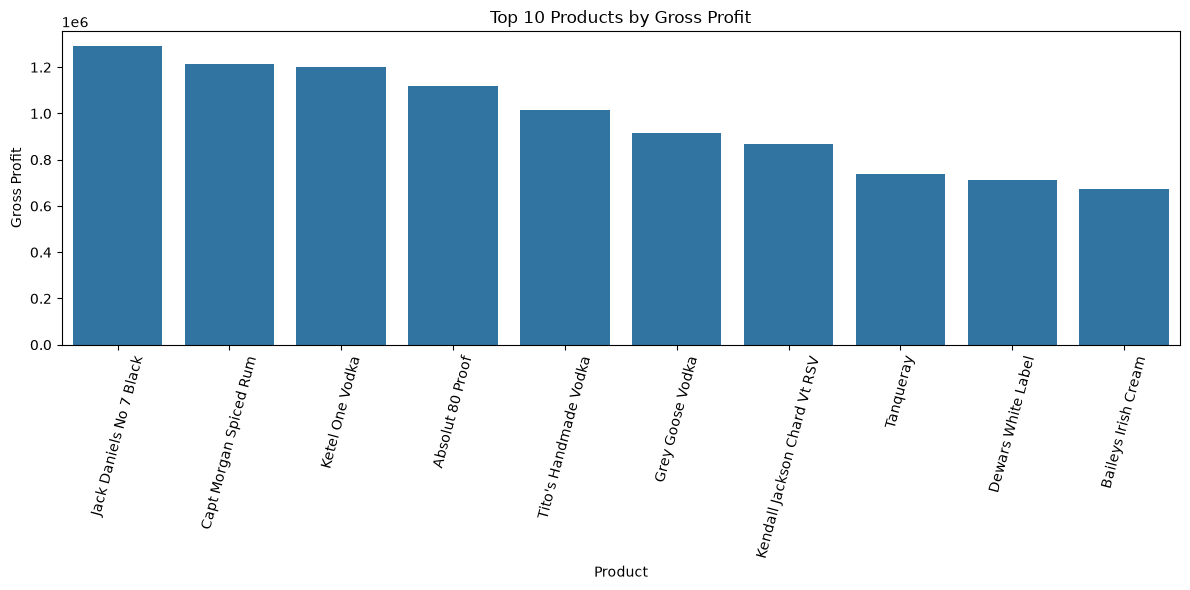

In [49]:
top_brands_profit = (
    brand_performance
    .sort_values("GrossProfit", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_brands_profit,
    x="Description",
    y="GrossProfit"
)

plt.title("Top 10 Products by Gross Profit")
plt.xlabel("Product")
plt.ylabel("Gross Profit")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

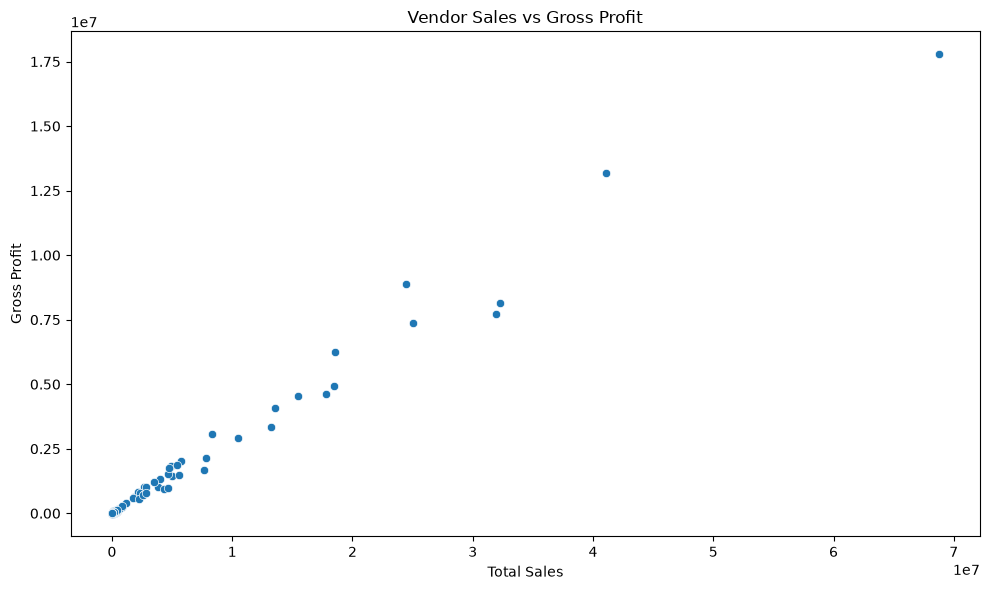

In [50]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=vendor_performance,
    x="TotalSales",
    y="GrossProfit"
)

plt.title("Vendor Sales vs Gross Profit")
plt.xlabel("Total Sales")
plt.ylabel("Gross Profit")
plt.tight_layout()
plt.show()

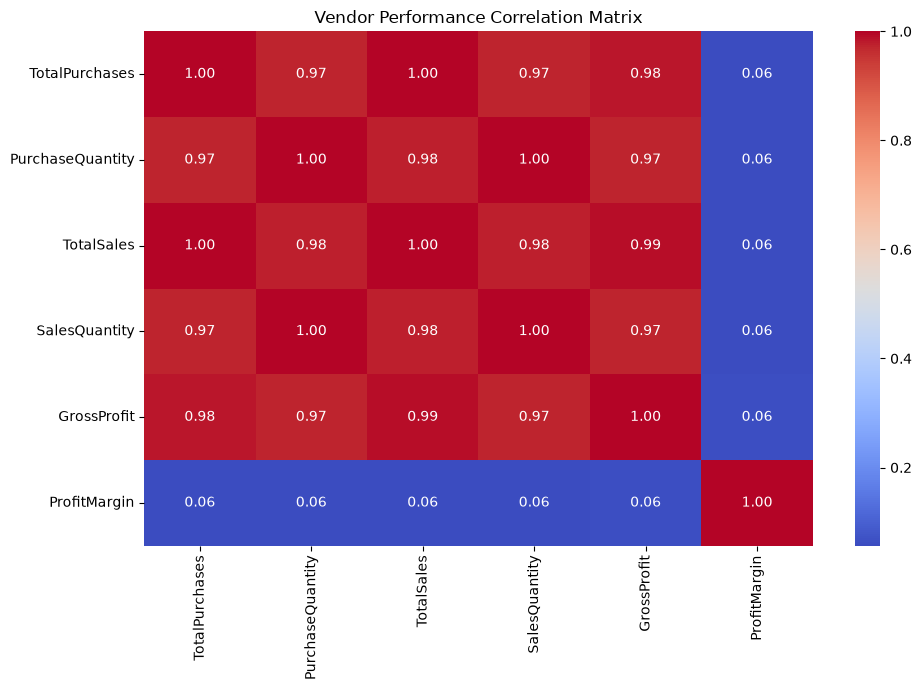

In [51]:
correlation_data = vendor_performance[
    [
        "TotalPurchases",
        "PurchaseQuantity",
        "TotalSales",
        "SalesQuantity",
        "GrossProfit",
        "ProfitMargin"
    ]
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_data.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Vendor Performance Correlation Matrix")
plt.tight_layout()
plt.show()

In [52]:
vendor_performance.to_csv(
    os.path.join(folder, "vendor_performance_final.csv"),
    index=False
)

brand_performance.to_csv(
    os.path.join(folder, "brand_performance.csv"),
    index=False
)

print("Final analysis files saved successfully!")

Final analysis files saved successfully!


In [53]:
print("Vendor Performance Summary")
display(
    vendor_performance[
        [
            "TotalPurchases",
            "TotalSales",
            "GrossProfit",
            "ProfitMargin",
            "PurchaseQuantity",
            "SalesQuantity"
        ]
    ].describe().T
)

Vendor Performance Summary


,count,mean,std,min,25%,50%,75%,max
TotalPurchases,129.0,2.495355e+06,6.509854e+06,0.000000,24035.960000,128895.690000,1.715909e+06,50959796.85
TotalSales,129.0,3.504364e+06,8.994885e+06,0.000000,29403.290000,149564.940000,2.586254e+06,68742416.99
GrossProfit,129.0,1.009009e+06,2.517696e+06,-9194.030000,3293.870000,33777.350000,7.748518e+05,17782620.14
ProfitMargin,129.0,7.757976e+00,1.419832e+02,-1478.652435,16.558682,27.156665,3.377047e+01,100.00
PurchaseQuantity,129.0,2.603440e+05,6.815762e+05,0.000000,1137.000000,9277.000000,1.864640e+05,5459788.00
SalesQuantity,129.0,2.551773e+05,6.714724e+05,0.000000,1115.000000,10141.000000,1.886250e+05,5422703.00


In [54]:
Q1 = vendor_performance["GrossProfit"].quantile(0.25)
Q3 = vendor_performance["GrossProfit"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

profit_outliers = vendor_performance[
    (vendor_performance["GrossProfit"] < lower_bound) |
    (vendor_performance["GrossProfit"] > upper_bound)
]

print("Number of profit outliers:", len(profit_outliers))

display(
    profit_outliers.sort_values(
        "GrossProfit",
        ascending=False
    ).head(20)
)

Number of profit outliers: 16


,VendorNumber,TotalPurchases,PurchaseQuantity,TotalSales,SalesQuantity,GrossProfit,ProfitMargin
41,3960,50959796.85,5459788.0,68742416.99,5422703.0,17782620.14,25.868483
43,4425,27861690.02,2640411.0,41047306.30,2581318.0,13185616.28,32.122976
17,1392,15573917.90,2325892.0,24469172.93,2301688.0,8895255.03,36.352904
101,17035,24124091.56,1647558.0,32281247.95,1613460.0,8157156.39,25.269024
97,12546,24203151.05,2737165.0,31906320.54,2630226.0,7703169.49,24.143083
7,480,17624378.72,1427075.0,25014556.89,1457301.0,7390178.17,29.543510
35,3252,12289608.09,1858260.0,18556085.61,1809023.0,6266477.52,33.770471
13,1128,13529433.08,1006122.0,18478557.47,983853.0,4949124.39,26.783067
81,9165,13210613.93,1077527.0,17822938.45,1043235.0,4612324.52,25.878586
84,9552,10935817.30,1372841.0,15465247.75,1343481.0,4529430.45,29.287798


In [55]:
Q1 = vendor_performance["GrossProfit"].quantile(0.25)
Q3 = vendor_performance["GrossProfit"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

profit_outliers = vendor_performance[
    (vendor_performance["GrossProfit"] < lower_bound) |
    (vendor_performance["GrossProfit"] > upper_bound)
]

print("Number of profit outliers:", len(profit_outliers))

display(
    profit_outliers.sort_values(
        "GrossProfit",
        ascending=False
    ).head(20)
)

Number of profit outliers: 16


,VendorNumber,TotalPurchases,PurchaseQuantity,TotalSales,SalesQuantity,GrossProfit,ProfitMargin
41,3960,50959796.85,5459788.0,68742416.99,5422703.0,17782620.14,25.868483
43,4425,27861690.02,2640411.0,41047306.30,2581318.0,13185616.28,32.122976
17,1392,15573917.90,2325892.0,24469172.93,2301688.0,8895255.03,36.352904
101,17035,24124091.56,1647558.0,32281247.95,1613460.0,8157156.39,25.269024
97,12546,24203151.05,2737165.0,31906320.54,2630226.0,7703169.49,24.143083
7,480,17624378.72,1427075.0,25014556.89,1457301.0,7390178.17,29.543510
35,3252,12289608.09,1858260.0,18556085.61,1809023.0,6266477.52,33.770471
13,1128,13529433.08,1006122.0,18478557.47,983853.0,4949124.39,26.783067
81,9165,13210613.93,1077527.0,17822938.45,1043235.0,4612324.52,25.878586
84,9552,10935817.30,1372841.0,15465247.75,1343481.0,4529430.45,29.287798


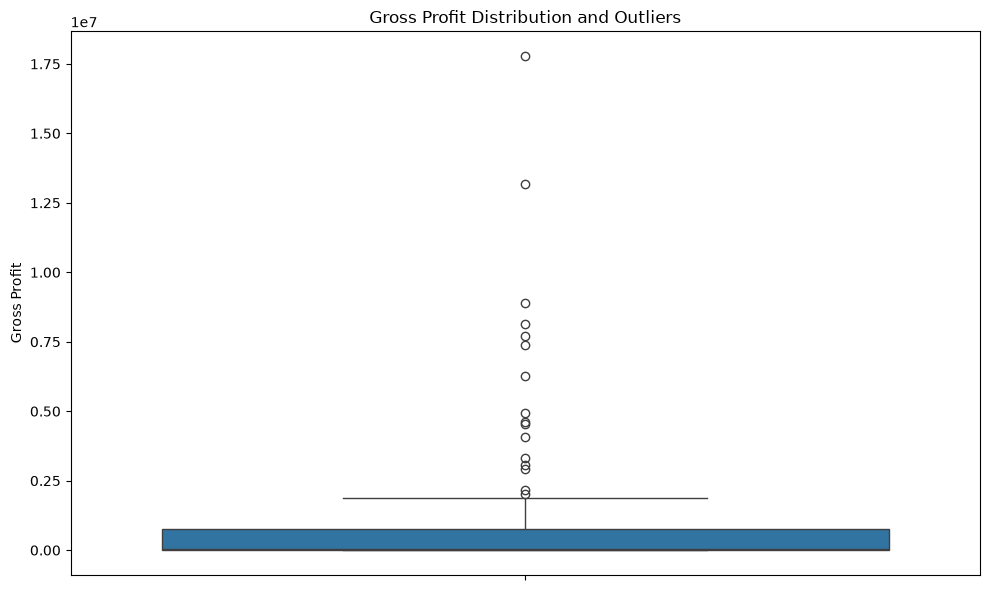

In [56]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    y=vendor_performance["GrossProfit"]
)

plt.title("Gross Profit Distribution and Outliers")
plt.ylabel("Gross Profit")
plt.tight_layout()
plt.show()

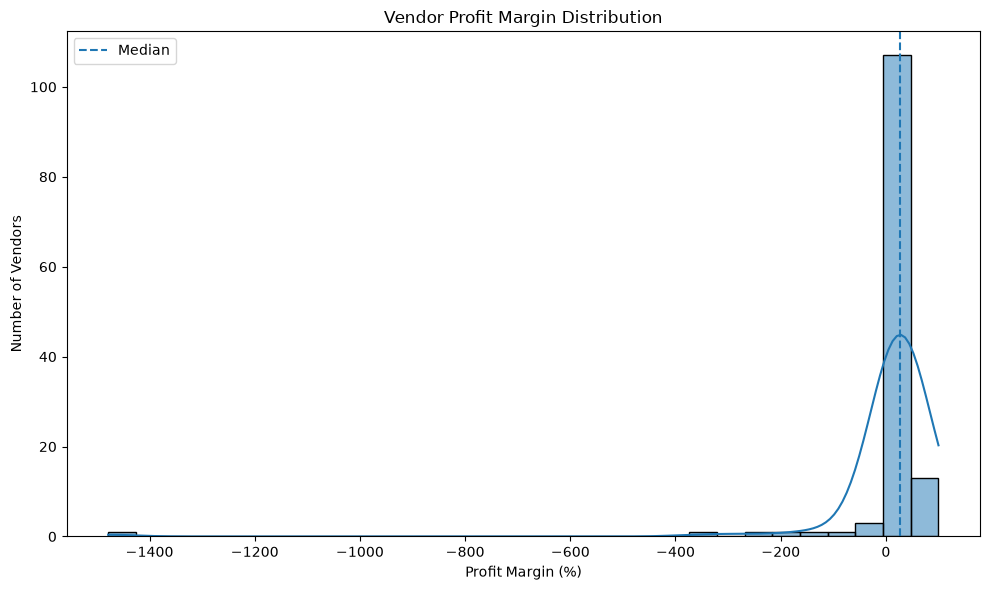

In [57]:
plt.figure(figsize=(10, 6))

sns.histplot(
    vendor_performance["ProfitMargin"],
    bins=30,
    kde=True
)

plt.axvline(
    vendor_performance["ProfitMargin"].median(),
    linestyle="--",
    label="Median"
)

plt.title("Vendor Profit Margin Distribution")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Number of Vendors")
plt.legend()
plt.tight_layout()
plt.show()

In [58]:
vendor_ranked = vendor_performance.sort_values(
    "TotalSales",
    ascending=False
).copy()

vendor_ranked["SalesPercentage"] = (
    vendor_ranked["TotalSales"]
    / vendor_ranked["TotalSales"].sum()
) * 100

vendor_ranked["CumulativeSalesPercentage"] = (
    vendor_ranked["SalesPercentage"].cumsum()
)

display(
    vendor_ranked[
        [
            "VendorNumber",
            "TotalSales",
            "SalesPercentage",
            "CumulativeSalesPercentage"
        ]
    ].head(20)
)

,VendorNumber,TotalSales,SalesPercentage,CumulativeSalesPercentage
41,3960,68742416.99,15.206381,15.206381
43,4425,41047306.30,9.079998,24.286379
101,17035,32281247.95,7.140874,31.427254
97,12546,31906320.54,7.057937,38.485191
7,480,25014556.89,5.533423,44.018615
17,1392,24469172.93,5.412780,49.431395
35,3252,18556085.61,4.104757,53.536152
13,1128,18478557.47,4.087607,57.623759
81,9165,17822938.45,3.942579,61.566338
84,9552,15465247.75,3.421039,64.987376


In [59]:
top10_contribution = (
    vendor_ranked.head(10)["TotalSales"].sum()
    / vendor_ranked["TotalSales"].sum()
) * 100

print(
    f"Top 10 vendors contribute "
    f"{top10_contribution:.2f}% of total sales."
)

Top 10 vendors contribute 64.99% of total sales.


In [60]:
sales_median = vendor_performance["TotalSales"].median()
profit_median = vendor_performance["GrossProfit"].median()

def classify_vendor(row):
    if (
        row["TotalSales"] >= sales_median
        and row["GrossProfit"] >= profit_median
    ):
        return "High Sales - High Profit"
    
    elif (
        row["TotalSales"] >= sales_median
        and row["GrossProfit"] < profit_median
    ):
        return "High Sales - Low Profit"
    
    elif (
        row["TotalSales"] < sales_median
        and row["GrossProfit"] >= profit_median
    ):
        return "Low Sales - High Profit"
    
    else:
        return "Low Sales - Low Profit"

vendor_performance["PerformanceCategory"] = (
    vendor_performance.apply(
        classify_vendor,
        axis=1
    )
)

display(
    vendor_performance[
        ["VendorNumber", "TotalSales", "GrossProfit", "PerformanceCategory"]
    ].head(20)
)

,VendorNumber,TotalSales,GrossProfit,PerformanceCategory
0,2,1265.58,-4365.30,Low Sales - Low Profit
1,54,0.00,-105.07,Low Sales - Low Profit
2,60,67576.22,-9194.03,Low Sales - Low Profit
3,105,15748.75,4042.55,Low Sales - Low Profit
4,200,1719.97,514.81,Low Sales - Low Profit
5,287,1616.92,-782.78,Low Sales - Low Profit
6,388,59272.75,18156.43,Low Sales - Low Profit
7,480,25014556.89,7390178.17,High Sales - High Profit
8,516,2646325.62,1017458.94,High Sales - High Profit
9,653,2299075.40,769393.36,High Sales - High Profit


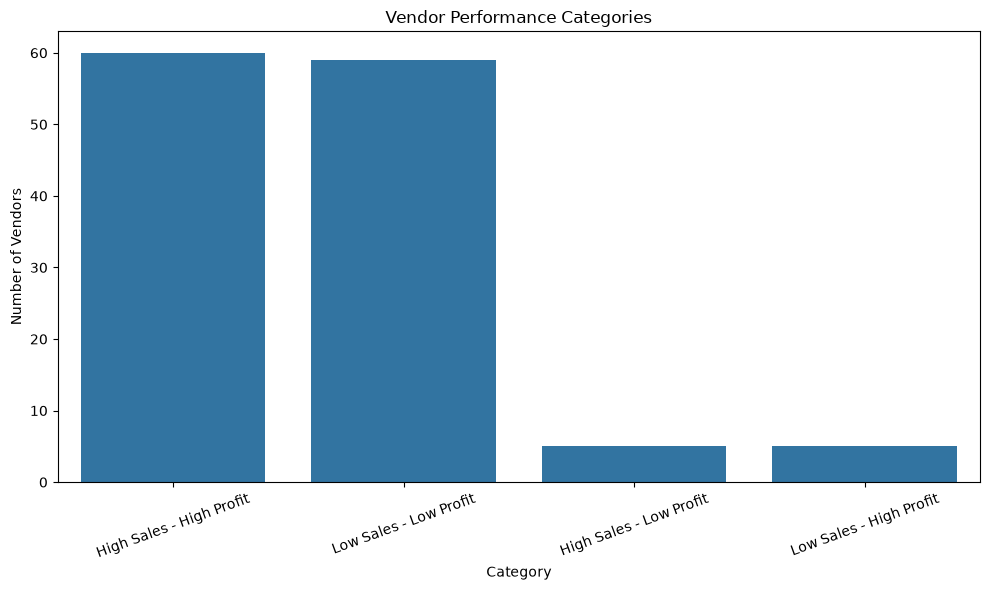

In [61]:
category_counts = (
    vendor_performance["PerformanceCategory"]
    .value_counts()
    .reset_index()
)

category_counts.columns = [
    "PerformanceCategory",
    "VendorCount"
]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_counts,
    x="PerformanceCategory",
    y="VendorCount"
)

plt.title("Vendor Performance Categories")
plt.xlabel("Category")
plt.ylabel("Number of Vendors")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [62]:
final_output = os.path.join(
    folder,
    "vendor_performance_final.csv"
)

vendor_performance.to_csv(
    final_output,
    index=False
)

print("Final vendor analysis saved successfully!")
print(final_output)

Final vendor analysis saved successfully!
C:\Users\Harshit\project data\vendor_performance_final.csv


In [63]:
import sqlite3

conn = sqlite3.connect("vendor_performance.db")

print("SQL database connected!")

SQL database connected!


In [64]:
begin_inventory.to_sql("begin_inventory", conn, if_exists="replace", index=False)
end_inventory.to_sql("end_inventory", conn, if_exists="replace", index=False)
purchases.to_sql("purchases", conn, if_exists="replace", index=False)
purchase_prices.to_sql("purchase_prices", conn, if_exists="replace", index=False)
sales.to_sql("sales", conn, if_exists="replace", index=False)
vendor_invoice.to_sql("vendor_invoice", conn, if_exists="replace", index=False)

print("All 6 datasets loaded into SQL!")

All 6 datasets loaded into SQL!


In [65]:
# Load all datasets into SQLite tables

begin_inventory.to_sql(
    "begin_inventory", conn, if_exists="replace", index=False
)

end_inventory.to_sql(
    "end_inventory", conn, if_exists="replace", index=False
)

purchases.to_sql(
    "purchases", conn, if_exists="replace", index=False
)

purchase_prices.to_sql(
    "purchase_prices", conn, if_exists="replace", index=False
)

sales.to_sql(
    "sales", conn, if_exists="replace", index=False
)

vendor_invoice.to_sql(
    "vendor_invoice", conn, if_exists="replace", index=False
)

print("All 6 datasets loaded into SQL successfully!")

All 6 datasets loaded into SQL successfully!


In [66]:
query = """
SELECT name
FROM sqlite_master
WHERE type = 'table';
"""

tables = pd.read_sql_query(query, conn)

display(tables)

,name
0,begin_inventory
1,end_inventory
2,purchases
3,purchase_prices
4,sales
5,vendor_invoice


In [67]:
query = """
SELECT
    VendorNumber,
    SUM(Dollars) AS TotalPurchases,
    SUM(Quantity) AS TotalQuantity
FROM purchases
GROUP BY VendorNumber
ORDER BY TotalPurchases DESC
LIMIT 10;
"""

top_vendors_sql = pd.read_sql_query(query, conn)

display(top_vendors_sql)

,VendorNumber,TotalPurchases,TotalQuantity
0,3960,50959796.85,5459788
1,4425,27861690.02,2640411
2,12546,24203151.05,2737165
3,17035,24124091.56,1647558
4,480,17624378.72,1427075
5,1392,15573917.90,2325892
6,1128,13529433.08,1006122
7,9165,13210613.93,1077527
8,3252,12289608.09,1858260
9,9552,10935817.30,1372841


In [68]:
query = """
SELECT
    VendorNo AS VendorNumber,
    SUM(SalesDollars) AS TotalSales,
    SUM(SalesQuantity) AS SalesQuantity
FROM sales
GROUP BY VendorNo
ORDER BY TotalSales DESC;
"""

vendor_sales_sql = pd.read_sql_query(query, conn)

display(vendor_sales_sql.head(10))

,VendorNumber,TotalSales,SalesQuantity
0,3960,68742416.99,5422703
1,4425,41047306.30,2581318
2,17035,32281247.95,1613460
3,12546,31906320.54,2630226
4,480,25014556.89,1457301
5,1392,24469172.93,2301688
6,3252,18556085.61,1809023
7,1128,18478557.47,983853
8,9165,17822938.45,1043235
9,9552,15465247.75,1343481


In [69]:
query = """
SELECT
    VendorNumber,
    SUM(Dollars) AS TotalPurchases,
    SUM(Quantity) AS PurchaseQuantity
FROM purchases
GROUP BY VendorNumber
ORDER BY TotalPurchases DESC;
"""

vendor_purchases_sql = pd.read_sql_query(query, conn)

display(vendor_purchases_sql.head(10))

,VendorNumber,TotalPurchases,PurchaseQuantity
0,3960,50959796.85,5459788
1,4425,27861690.02,2640411
2,12546,24203151.05,2737165
3,17035,24124091.56,1647558
4,480,17624378.72,1427075
5,1392,15573917.90,2325892
6,1128,13529433.08,1006122
7,9165,13210613.93,1077527
8,3252,12289608.09,1858260
9,9552,10935817.30,1372841


In [70]:
query = """
WITH purchase_summary AS (
    SELECT
        VendorNumber,
        SUM(Dollars) AS TotalPurchases,
        SUM(Quantity) AS PurchaseQuantity
    FROM purchases
    GROUP BY VendorNumber
),

sales_summary AS (
    SELECT
        VendorNo AS VendorNumber,
        SUM(SalesDollars) AS TotalSales,
        SUM(SalesQuantity) AS SalesQuantity
    FROM sales
    GROUP BY VendorNo
)

SELECT
    p.VendorNumber,
    p.TotalPurchases,
    p.PurchaseQuantity,
    COALESCE(s.TotalSales, 0) AS TotalSales,
    COALESCE(s.SalesQuantity, 0) AS SalesQuantity,
    COALESCE(s.TotalSales, 0) - p.TotalPurchases AS GrossProfit
FROM purchase_summary p
LEFT JOIN sales_summary s
    ON p.VendorNumber = s.VendorNumber
ORDER BY GrossProfit DESC;
"""

vendor_sql_analysis = pd.read_sql_query(query, conn)

display(vendor_sql_analysis.head(10))

,VendorNumber,TotalPurchases,PurchaseQuantity,TotalSales,SalesQuantity,GrossProfit
0,3960,50959796.85,5459788,68742416.99,5422703,17782620.14
1,4425,27861690.02,2640411,41047306.30,2581318,13185616.28
2,1392,15573917.90,2325892,24469172.93,2301688,8895255.03
3,17035,24124091.56,1647558,32281247.95,1613460,8157156.39
4,12546,24203151.05,2737165,31906320.54,2630226,7703169.49
5,480,17624378.72,1427075,25014556.89,1457301,7390178.17
6,3252,12289608.09,1858260,18556085.61,1809023,6266477.52
7,1128,13529433.08,1006122,18478557.47,983853,4949124.39
8,9165,13210613.93,1077527,17822938.45,1043235,4612324.52
9,9552,10935817.30,1372841,15465247.75,1343481,4529430.45


In [71]:
vendor_sql_analysis["ProfitMargin"] = np.where(
    vendor_sql_analysis["TotalSales"] > 0,
    (
        vendor_sql_analysis["GrossProfit"]
        / vendor_sql_analysis["TotalSales"]
    ) * 100,
    0
)

display(
    vendor_sql_analysis.head(10)
)

,VendorNumber,TotalPurchases,PurchaseQuantity,TotalSales,SalesQuantity,GrossProfit,ProfitMargin
0,3960,50959796.85,5459788,68742416.99,5422703,17782620.14,25.868483
1,4425,27861690.02,2640411,41047306.30,2581318,13185616.28,32.122976
2,1392,15573917.90,2325892,24469172.93,2301688,8895255.03,36.352904
3,17035,24124091.56,1647558,32281247.95,1613460,8157156.39,25.269024
4,12546,24203151.05,2737165,31906320.54,2630226,7703169.49,24.143083
5,480,17624378.72,1427075,25014556.89,1457301,7390178.17,29.543510
6,3252,12289608.09,1858260,18556085.61,1809023,6266477.52,33.770471
7,1128,13529433.08,1006122,18478557.47,983853,4949124.39,26.783067
8,9165,13210613.93,1077527,17822938.45,1043235,4612324.52,25.878586
9,9552,10935817.30,1372841,15465247.75,1343481,4529430.45,29.287798


In [72]:
print("SQL vendor analysis shape:")
print(vendor_sql_analysis.shape)

print("\nColumns:")
print(vendor_sql_analysis.columns.tolist())

SQL vendor analysis shape:
(126, 7)

Columns:
['VendorNumber', 'TotalPurchases', 'PurchaseQuantity', 'TotalSales', 'SalesQuantity', 'GrossProfit', 'ProfitMargin']


In [73]:
query = """
WITH vendor_sales AS (
    SELECT
        VendorNo AS VendorNumber,
        SUM(SalesDollars) AS TotalSales
    FROM sales
    GROUP BY VendorNo
)

SELECT
    VendorNumber,
    TotalSales,
    ROUND(
        TotalSales * 100.0 /
        (SELECT SUM(TotalSales) FROM vendor_sales),
        2
    ) AS SalesContributionPercent
FROM vendor_sales
ORDER BY TotalSales DESC
LIMIT 15;
"""

top_vendor_contribution = pd.read_sql_query(query, conn)

display(top_vendor_contribution)

,VendorNumber,TotalSales,SalesContributionPercent
0,3960,68742416.99,15.21
1,4425,41047306.30,9.08
2,17035,32281247.95,7.14
3,12546,31906320.54,7.06
4,480,25014556.89,5.53
5,1392,24469172.93,5.41
6,3252,18556085.61,4.10
7,1128,18478557.47,4.09
8,9165,17822938.45,3.94
9,9552,15465247.75,3.42


In [74]:
query = """
SELECT
    VendorNumber,
    SUM(Dollars) AS InvoiceDollars,
    SUM(Freight) AS TotalFreight,
    ROUND(
        SUM(Freight) * 100.0 / NULLIF(SUM(Dollars), 0),
        2
    ) AS FreightPercentage
FROM vendor_invoice
GROUP BY VendorNumber
ORDER BY TotalFreight DESC
LIMIT 15;
"""

freight_analysis = pd.read_sql_query(query, conn)

display(freight_analysis)

,VendorNumber,InvoiceDollars,TotalFreight,FreightPercentage
0,3960,50959796.85,257032.07,0.50
1,4425,27861690.02,144929.24,0.52
2,12546,24203151.05,123880.97,0.51
3,17035,24124091.56,123780.22,0.51
4,480,17624378.72,89286.27,0.51
5,1392,15573917.90,79528.99,0.51
6,1128,13529433.08,68601.68,0.51
7,9165,13210613.93,68054.70,0.52
8,3252,12289608.09,61966.91,0.50
9,9552,10935817.30,55551.82,0.51


In [75]:
query = """
WITH purchases_summary AS (
    SELECT
        VendorNumber,
        SUM(Dollars) AS TotalPurchases
    FROM purchases
    GROUP BY VendorNumber
),

sales_summary AS (
    SELECT
        VendorNo AS VendorNumber,
        SUM(SalesDollars) AS TotalSales
    FROM sales
    GROUP BY VendorNo
),

freight_summary AS (
    SELECT
        VendorNumber,
        SUM(Freight) AS TotalFreight
    FROM vendor_invoice
    GROUP BY VendorNumber
)

SELECT
    p.VendorNumber,
    p.TotalPurchases,
    COALESCE(s.TotalSales, 0) AS TotalSales,
    COALESCE(f.TotalFreight, 0) AS TotalFreight,

    COALESCE(s.TotalSales, 0) - p.TotalPurchases
        AS GrossProfit,

    ROUND(
        (
            COALESCE(s.TotalSales, 0) - p.TotalPurchases
        ) * 100.0 /
        NULLIF(COALESCE(s.TotalSales, 0), 0),
        2
    ) AS ProfitMargin

FROM purchases_summary p

LEFT JOIN sales_summary s
    ON p.VendorNumber = s.VendorNumber

LEFT JOIN freight_summary f
    ON p.VendorNumber = f.VendorNumber

ORDER BY GrossProfit DESC;
"""

vendor_final_sql = pd.read_sql_query(query, conn)

display(vendor_final_sql.head(15))

,VendorNumber,TotalPurchases,TotalSales,TotalFreight,GrossProfit,ProfitMargin
0,3960,50959796.85,68742416.99,257032.07,17782620.14,25.87
1,4425,27861690.02,41047306.30,144929.24,13185616.28,32.12
2,1392,15573917.90,24469172.93,79528.99,8895255.03,36.35
3,17035,24124091.56,32281247.95,123780.22,8157156.39,25.27
4,12546,24203151.05,31906320.54,123880.97,7703169.49,24.14
5,480,17624378.72,25014556.89,89286.27,7390178.17,29.54
6,3252,12289608.09,18556085.61,61966.91,6266477.52,33.77
7,1128,13529433.08,18478557.47,68601.68,4949124.39,26.78
8,9165,13210613.93,17822938.45,68054.70,4612324.52,25.88
9,9552,10935817.30,15465247.75,55551.82,4529430.45,29.29


In [76]:
query = """
WITH purchase_summary AS (
    SELECT
        VendorNumber,
        SUM(Dollars) AS TotalPurchases
    FROM purchases
    GROUP BY VendorNumber
),

sales_summary AS (
    SELECT
        VendorNo AS VendorNumber,
        SUM(SalesDollars) AS TotalSales
    FROM sales
    GROUP BY VendorNo
)

SELECT
    p.VendorNumber,
    p.TotalPurchases,
    COALESCE(s.TotalSales, 0) AS TotalSales,

    COALESCE(s.TotalSales, 0) - p.TotalPurchases
        AS GrossProfit,

    ROUND(
        (
            COALESCE(s.TotalSales, 0)
            - p.TotalPurchases
        ) * 100.0
        / NULLIF(COALESCE(s.TotalSales, 0), 0),
        2
    ) AS ProfitMargin

FROM purchase_summary p

LEFT JOIN sales_summary s
    ON p.VendorNumber = s.VendorNumber

ORDER BY GrossProfit DESC;
"""

vendor_final_sql = pd.read_sql_query(query, conn)

display(vendor_final_sql.head(15))

,VendorNumber,TotalPurchases,TotalSales,GrossProfit,ProfitMargin
0,3960,50959796.85,68742416.99,17782620.14,25.87
1,4425,27861690.02,41047306.30,13185616.28,32.12
2,1392,15573917.90,24469172.93,8895255.03,36.35
3,17035,24124091.56,32281247.95,8157156.39,25.27
4,12546,24203151.05,31906320.54,7703169.49,24.14
5,480,17624378.72,25014556.89,7390178.17,29.54
6,3252,12289608.09,18556085.61,6266477.52,33.77
7,1128,13529433.08,18478557.47,4949124.39,26.78
8,9165,13210613.93,17822938.45,4612324.52,25.88
9,9552,10935817.30,15465247.75,4529430.45,29.29


In [77]:
vendor_final_sql.to_csv(
    os.path.join(folder, "vendor_sql_analysis.csv"),
    index=False
)

print("SQL analysis exported successfully!")

SQL analysis exported successfully!


In [78]:
vendor_performance = vendor_final_sql.copy()

print("Rows:", vendor_performance.shape[0])
print("Columns:", vendor_performance.columns.tolist())

display(vendor_performance.head())

Rows: 126
Columns: ['VendorNumber', 'TotalPurchases', 'TotalSales', 'GrossProfit', 'ProfitMargin']


,VendorNumber,TotalPurchases,TotalSales,GrossProfit,ProfitMargin
0,3960,50959796.85,68742416.99,17782620.14,25.87
1,4425,27861690.02,41047306.30,13185616.28,32.12
2,1392,15573917.90,24469172.93,8895255.03,36.35
3,17035,24124091.56,32281247.95,8157156.39,25.27
4,12546,24203151.05,31906320.54,7703169.49,24.14


In [80]:
freight_query = """
SELECT
    VendorNumber,
    SUM(Freight) AS TotalFreight
FROM vendor_invoice
GROUP BY VendorNumber
"""

freight_sql = pd.read_sql_query(freight_query, conn)

display(freight_sql.head())

,VendorNumber,TotalFreight
0,2,27.08
1,54,0.48
2,60,367.52
3,105,62.39
4,200,6.19


In [81]:
vendor_performance = vendor_final_sql.merge(
    freight_sql,
    on="VendorNumber",
    how="left"
)

vendor_performance["TotalFreight"] = (
    vendor_performance["TotalFreight"].fillna(0)
)

In [82]:
vendor_performance["FreightPercentage"] = np.where(
    vendor_performance["TotalPurchases"] > 0,
    (
        vendor_performance["TotalFreight"]
        / vendor_performance["TotalPurchases"]
    ) * 100,
    0
)

In [83]:
display(
    vendor_performance[
        [
            "TotalPurchases",
            "TotalSales",
            "TotalFreight",
            "GrossProfit",
            "ProfitMargin"
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
TotalPurchases,126.0,2.554768e+06,6.575886e+06,17.00,24910.3200,139742.585,1.785087e+06,50959796.85
TotalSales,126.0,3.587800e+06,9.085593e+06,0.00,35487.6025,177949.915,2.620582e+06,68742416.99
TotalFreight,126.0,1.301964e+04,3.346990e+04,0.09,125.8525,718.120,8.991922e+03,257032.07
GrossProfit,126.0,1.033032e+06,2.542816e+06,-9194.03,4336.9450,35323.535,7.909254e+05,17782620.14
ProfitMargin,124.0,5.651210e+00,1.441030e+02,-1478.65,17.0550,27.115,3.357750e+01,98.85


In [84]:
top_sales = (
    vendor_performance
    .sort_values("TotalSales", ascending=False)
    .head(10)
)

display(top_sales)

,VendorNumber,TotalPurchases,TotalSales,GrossProfit,ProfitMargin,TotalFreight,FreightPercentage
0,3960,50959796.85,68742416.99,17782620.14,25.87,257032.07,0.504382
1,4425,27861690.02,41047306.30,13185616.28,32.12,144929.24,0.520174
3,17035,24124091.56,32281247.95,8157156.39,25.27,123780.22,0.513098
4,12546,24203151.05,31906320.54,7703169.49,24.14,123880.97,0.511838
5,480,17624378.72,25014556.89,7390178.17,29.54,89286.27,0.506607
2,1392,15573917.90,24469172.93,8895255.03,36.35,79528.99,0.510655
6,3252,12289608.09,18556085.61,6266477.52,33.77,61966.91,0.504222
7,1128,13529433.08,18478557.47,4949124.39,26.78,68601.68,0.507055
8,9165,13210613.93,17822938.45,4612324.52,25.88,68054.70,0.515152
9,9552,10935817.30,15465247.75,4529430.45,29.29,55551.82,0.507981


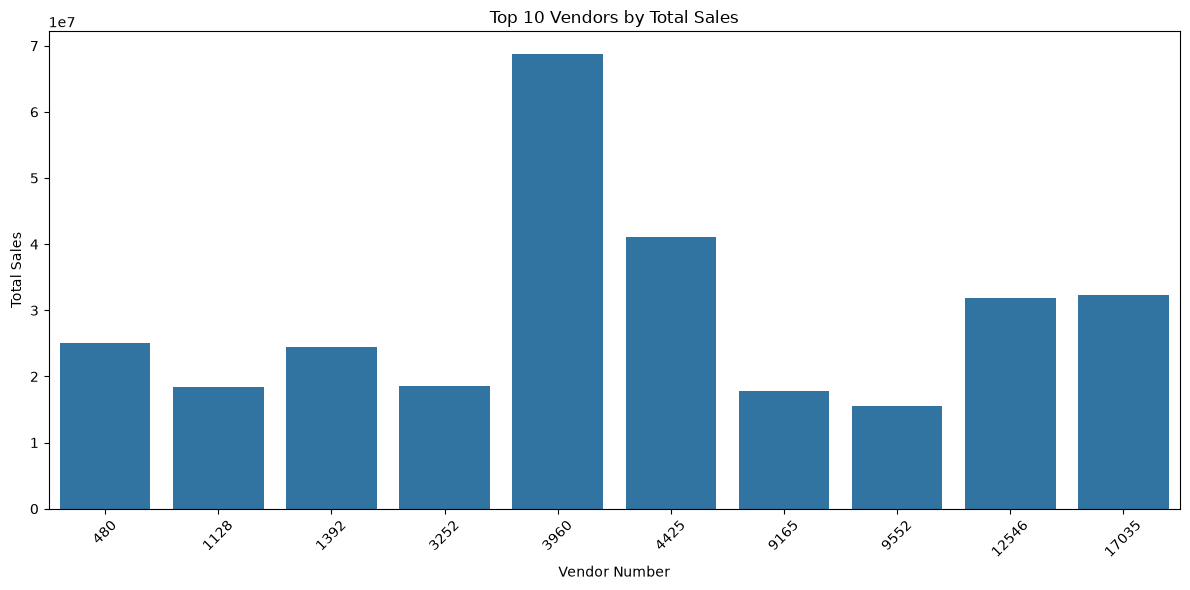

In [85]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_sales,
    x="VendorNumber",
    y="TotalSales"
)

plt.title("Top 10 Vendors by Total Sales")
plt.xlabel("Vendor Number")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [86]:
top_profit = (
    vendor_performance
    .sort_values("GrossProfit", ascending=False)
    .head(10)
)

display(top_profit)

,VendorNumber,TotalPurchases,TotalSales,GrossProfit,ProfitMargin,TotalFreight,FreightPercentage
0,3960,50959796.85,68742416.99,17782620.14,25.87,257032.07,0.504382
1,4425,27861690.02,41047306.30,13185616.28,32.12,144929.24,0.520174
2,1392,15573917.90,24469172.93,8895255.03,36.35,79528.99,0.510655
3,17035,24124091.56,32281247.95,8157156.39,25.27,123780.22,0.513098
4,12546,24203151.05,31906320.54,7703169.49,24.14,123880.97,0.511838
5,480,17624378.72,25014556.89,7390178.17,29.54,89286.27,0.506607
6,3252,12289608.09,18556085.61,6266477.52,33.77,61966.91,0.504222
7,1128,13529433.08,18478557.47,4949124.39,26.78,68601.68,0.507055
8,9165,13210613.93,17822938.45,4612324.52,25.88,68054.70,0.515152
9,9552,10935817.30,15465247.75,4529430.45,29.29,55551.82,0.507981


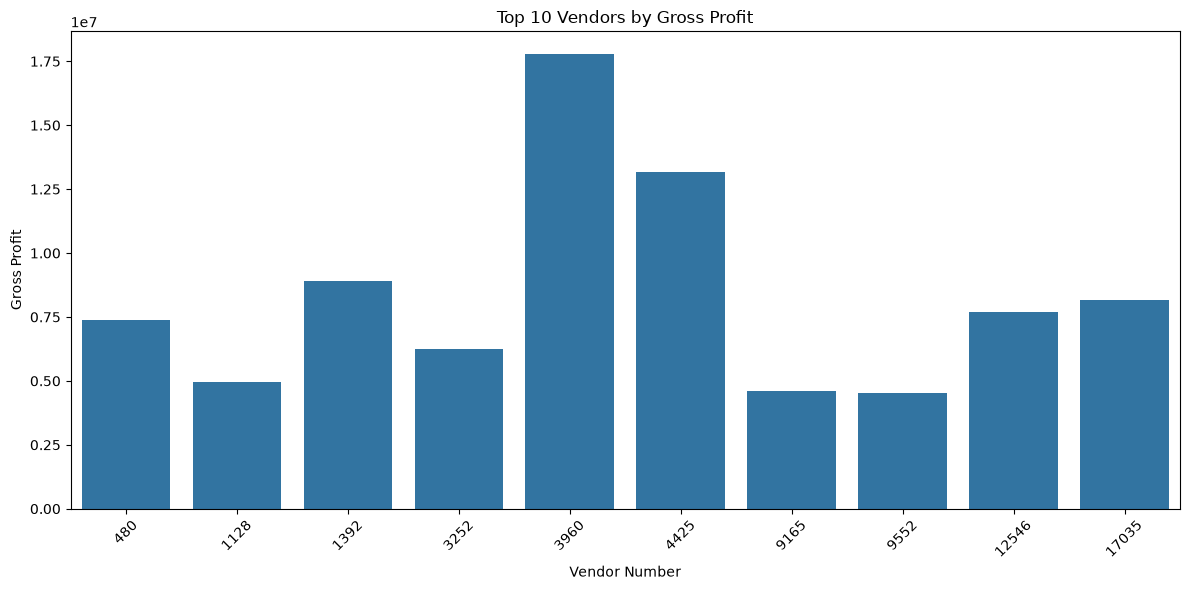

In [87]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_profit,
    x="VendorNumber",
    y="GrossProfit"
)

plt.title("Top 10 Vendors by Gross Profit")
plt.xlabel("Vendor Number")
plt.ylabel("Gross Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

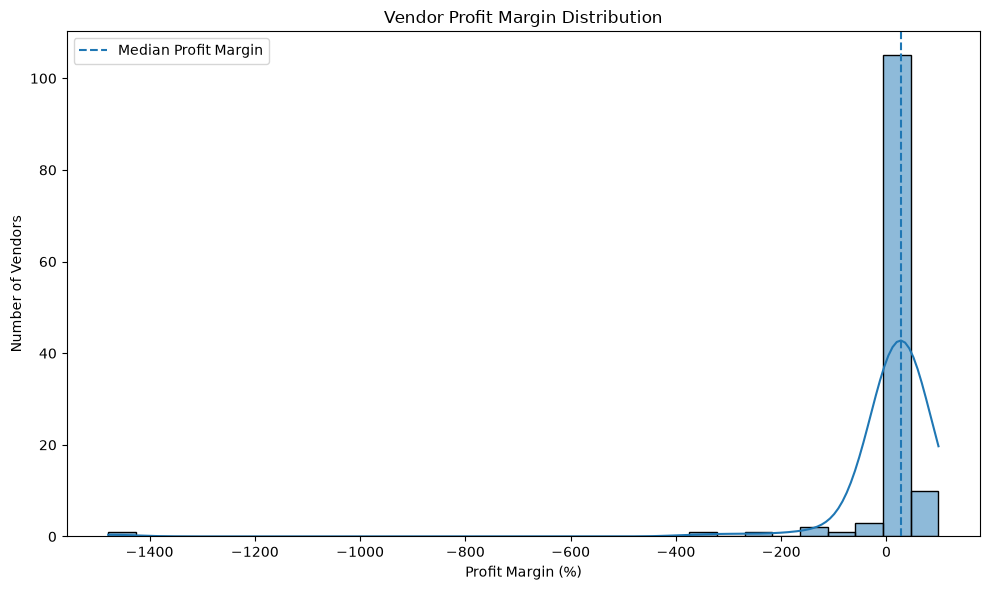

In [88]:
plt.figure(figsize=(10, 6))

sns.histplot(
    vendor_performance["ProfitMargin"],
    bins=30,
    kde=True
)

plt.axvline(
    vendor_performance["ProfitMargin"].median(),
    linestyle="--",
    label="Median Profit Margin"
)

plt.title("Vendor Profit Margin Distribution")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Number of Vendors")
plt.legend()
plt.tight_layout()
plt.show()

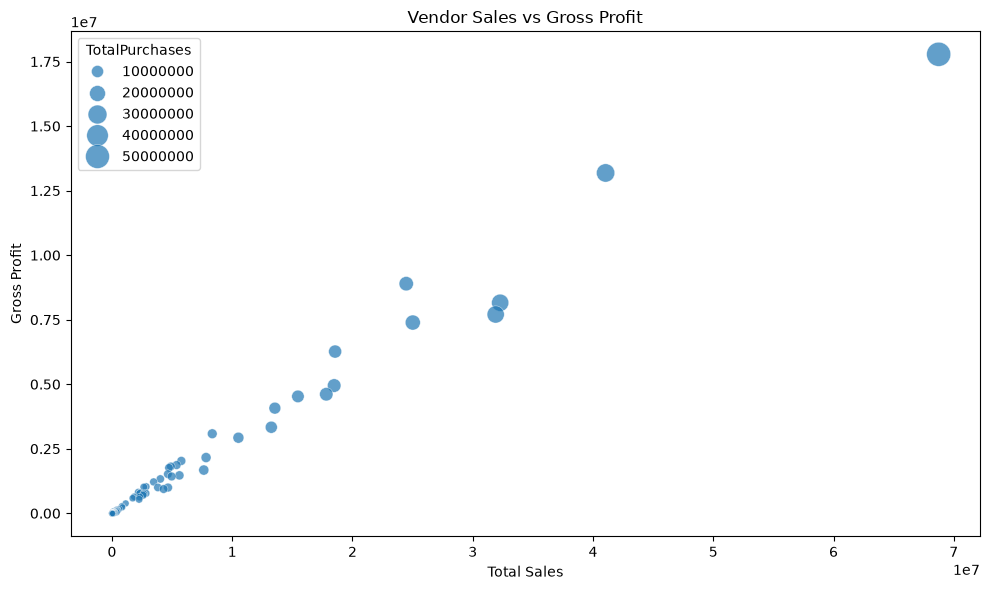

In [89]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=vendor_performance,
    x="TotalSales",
    y="GrossProfit",
    size="TotalPurchases",
    sizes=(20, 300),
    alpha=0.7
)

plt.title("Vendor Sales vs Gross Profit")
plt.xlabel("Total Sales")
plt.ylabel("Gross Profit")
plt.tight_layout()
plt.show()

In [90]:
sales_median = vendor_performance["TotalSales"].median()
margin_median = vendor_performance["ProfitMargin"].median()

high_sales_low_margin = vendor_performance[
    (vendor_performance["TotalSales"] >= sales_median) &
    (vendor_performance["ProfitMargin"] < margin_median)
].sort_values("TotalSales", ascending=False)

display(high_sales_low_margin.head(15))

,VendorNumber,TotalPurchases,TotalSales,GrossProfit,ProfitMargin,TotalFreight,FreightPercentage
0,3960,50959796.85,68742416.99,17782620.14,25.87,257032.07,0.504382
3,17035,24124091.56,32281247.95,8157156.39,25.27,123780.22,0.513098
4,12546,24203151.05,31906320.54,7703169.49,24.14,123880.97,0.511838
7,1128,13529433.08,18478557.47,4949124.39,26.78,68601.68,0.507055
8,9165,13210613.93,17822938.45,4612324.52,25.88,68054.70,0.515152
11,8004,9916770.26,13250928.19,3334157.93,25.16,50293.62,0.507157
19,3664,5960744.35,7635828.27,1675083.92,21.94,30234.42,0.507226
21,11567,4141720.71,5610527.44,1468806.73,26.18,20964.81,0.506186
28,8664,3666478.72,4663847.60,997368.88,21.39,18544.49,0.505785
29,7239,3354958.28,4294875.05,939916.77,21.88,16978.67,0.506077


In [91]:
vendor_performance["FreightPercentage"] = np.where(
    vendor_performance["TotalPurchases"] > 0,
    (vendor_performance["TotalFreight"]
     / vendor_performance["TotalPurchases"]) * 100,
    0
)

display(
    vendor_performance
    .sort_values("FreightPercentage", ascending=False)
    .head(15)
)

,VendorNumber,TotalPurchases,TotalSales,GrossProfit,ProfitMargin,TotalFreight,FreightPercentage
103,28776,48445.58,49533.14,1087.56,2.20,259.90,0.536478
51,9625,361249.21,443217.71,81968.50,18.49,1933.19,0.535140
122,3951,5500.32,1533.68,-3966.64,-258.64,29.43,0.535060
94,105,11706.20,15748.75,4042.55,25.67,62.39,0.532965
30,1590,1365472.83,2185030.89,819558.06,37.51,7259.75,0.531666
78,90046,36588.01,52623.33,16035.32,30.47,194.13,0.530584
53,90032,146839.55,203067.70,56228.15,27.69,778.25,0.530000
101,201359,17.00,1474.41,1457.41,98.85,0.09,0.529412
115,9099,236.64,14.99,-221.65,-1478.65,1.25,0.528229
107,10050,138907.27,139327.43,420.16,0.30,732.60,0.527402


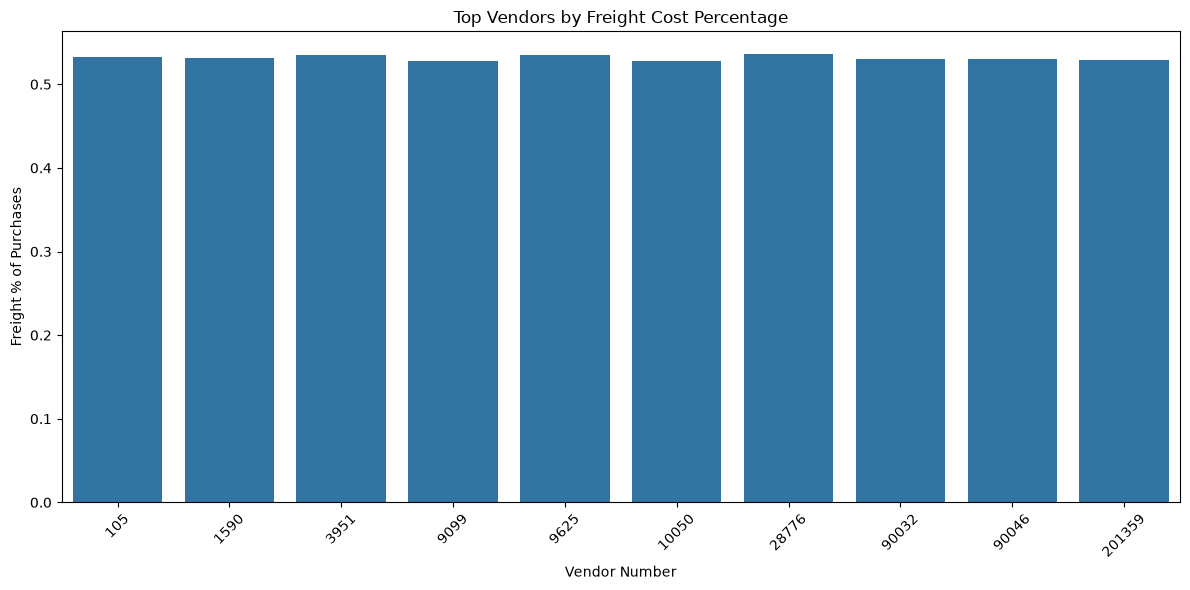

In [92]:
top_freight = (
    vendor_performance
    .sort_values("FreightPercentage", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_freight,
    x="VendorNumber",
    y="FreightPercentage"
)

plt.title("Top Vendors by Freight Cost Percentage")
plt.xlabel("Vendor Number")
plt.ylabel("Freight % of Purchases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

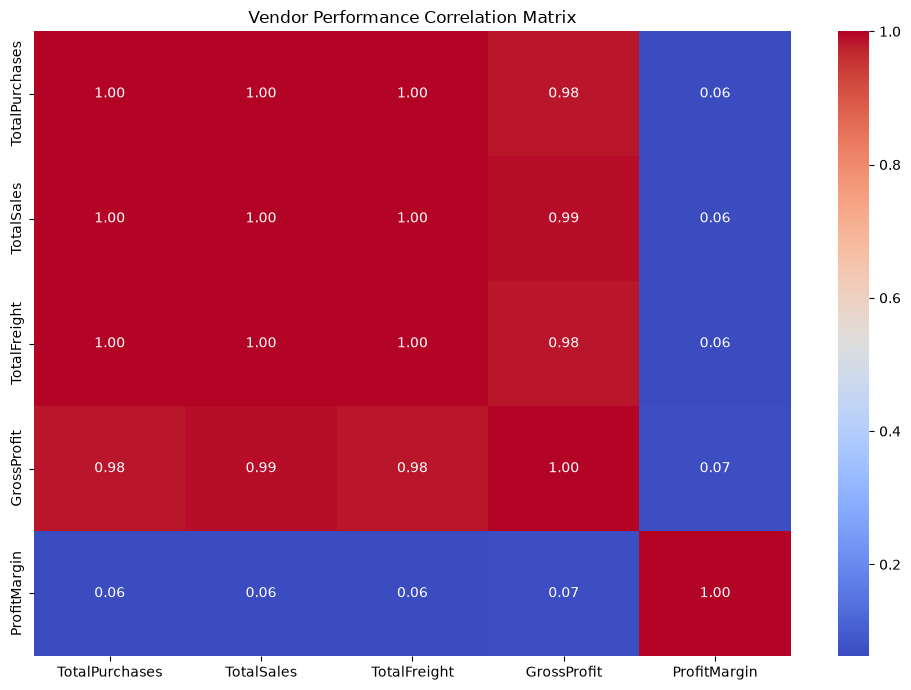

In [93]:
correlation_columns = [
    "TotalPurchases",
    "TotalSales",
    "TotalFreight",
    "GrossProfit",
    "ProfitMargin"
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    vendor_performance[correlation_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Vendor Performance Correlation Matrix")
plt.tight_layout()
plt.show()

In [94]:
correlation_columns = [
    "TotalPurchases",
    "TotalSales",
    "TotalFreight",
    "GrossProfit",
    "ProfitMargin"
]

correlation_matrix = vendor_performance[
    correlation_columns
].corr()

display(correlation_matrix)

,TotalPurchases,TotalSales,TotalFreight,GrossProfit,ProfitMargin
TotalPurchases,1.000000,0.998600,0.999932,0.981978,0.062569
TotalSales,0.998600,1.000000,0.998784,0.990600,0.064521
TotalFreight,0.999932,0.998784,1.000000,0.982811,0.062680
GrossProfit,0.981978,0.990600,0.982811,1.000000,0.068727
ProfitMargin,0.062569,0.064521,0.062680,0.068727,1.000000


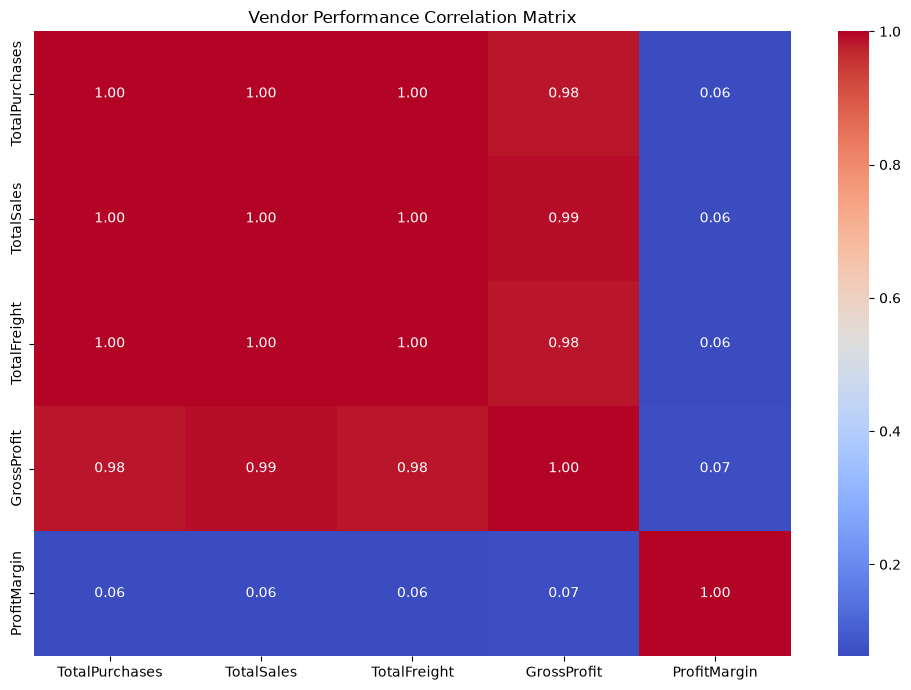

In [95]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Vendor Performance Correlation Matrix")
plt.tight_layout()
plt.show()

In [96]:
sales_median = vendor_performance["TotalSales"].median()
margin_median = vendor_performance["ProfitMargin"].median()

high_sales_low_margin = vendor_performance[
    (vendor_performance["TotalSales"] >= sales_median) &
    (vendor_performance["ProfitMargin"] < margin_median)
].sort_values(
    "TotalSales",
    ascending=False
)

display(high_sales_low_margin.head(15))

,VendorNumber,TotalPurchases,TotalSales,GrossProfit,ProfitMargin,TotalFreight,FreightPercentage
0,3960,50959796.85,68742416.99,17782620.14,25.87,257032.07,0.504382
3,17035,24124091.56,32281247.95,8157156.39,25.27,123780.22,0.513098
4,12546,24203151.05,31906320.54,7703169.49,24.14,123880.97,0.511838
7,1128,13529433.08,18478557.47,4949124.39,26.78,68601.68,0.507055
8,9165,13210613.93,17822938.45,4612324.52,25.88,68054.70,0.515152
11,8004,9916770.26,13250928.19,3334157.93,25.16,50293.62,0.507157
19,3664,5960744.35,7635828.27,1675083.92,21.94,30234.42,0.507226
21,11567,4141720.71,5610527.44,1468806.73,26.18,20964.81,0.506186
28,8664,3666478.72,4663847.60,997368.88,21.39,18544.49,0.505785
29,7239,3354958.28,4294875.05,939916.77,21.88,16978.67,0.506077


In [97]:
vendor_ranked = vendor_performance.sort_values(
    "TotalSales",
    ascending=False
).copy()

vendor_ranked["SalesPercentage"] = (
    vendor_ranked["TotalSales"]
    / vendor_ranked["TotalSales"].sum()
) * 100

vendor_ranked["CumulativeSalesPercentage"] = (
    vendor_ranked["SalesPercentage"].cumsum()
)

display(
    vendor_ranked[
        [
            "VendorNumber",
            "TotalSales",
            "SalesPercentage",
            "CumulativeSalesPercentage"
        ]
    ].head(20)
)

,VendorNumber,TotalSales,SalesPercentage,CumulativeSalesPercentage
0,3960,68742416.99,15.206385,15.206385
1,4425,41047306.30,9.080000,24.286385
3,17035,32281247.95,7.140876,31.427261
4,12546,31906320.54,7.057939,38.485200
5,480,25014556.89,5.533425,44.018625
2,1392,24469172.93,5.412781,49.431406
6,3252,18556085.61,4.104758,53.536164
7,1128,18478557.47,4.087608,57.623772
8,9165,17822938.45,3.942580,61.566352
9,9552,15465247.75,3.421039,64.987391


In [98]:
top10_contribution = (
    vendor_ranked.head(10)["TotalSales"].sum()
    / vendor_ranked["TotalSales"].sum()
) * 100

print(
    f"Top 10 vendors contribute "
    f"{top10_contribution:.2f}% of total sales."
)

Top 10 vendors contribute 64.99% of total sales.


In [99]:
sales_median = vendor_performance["TotalSales"].median()
profit_median = vendor_performance["GrossProfit"].median()

def classify_vendor(row):
    if row["TotalSales"] >= sales_median and row["GrossProfit"] >= profit_median:
        return "High Sales - High Profit"
    elif row["TotalSales"] >= sales_median and row["GrossProfit"] < profit_median:
        return "High Sales - Low Profit"
    elif row["TotalSales"] < sales_median and row["GrossProfit"] >= profit_median:
        return "Low Sales - High Profit"
    else:
        return "Low Sales - Low Profit"

vendor_performance["PerformanceCategory"] = (
    vendor_performance.apply(classify_vendor, axis=1)
)

display(
    vendor_performance[
        ["VendorNumber", "TotalSales", "GrossProfit", "ProfitMargin",
         "PerformanceCategory"]
    ].head(15)
)

,VendorNumber,TotalSales,GrossProfit,ProfitMargin,PerformanceCategory
0,3960,68742416.99,17782620.14,25.87,High Sales - High Profit
1,4425,41047306.30,13185616.28,32.12,High Sales - High Profit
2,1392,24469172.93,8895255.03,36.35,High Sales - High Profit
3,17035,32281247.95,8157156.39,25.27,High Sales - High Profit
4,12546,31906320.54,7703169.49,24.14,High Sales - High Profit
5,480,25014556.89,7390178.17,29.54,High Sales - High Profit
6,3252,18556085.61,6266477.52,33.77,High Sales - High Profit
7,1128,18478557.47,4949124.39,26.78,High Sales - High Profit
8,9165,17822938.45,4612324.52,25.88,High Sales - High Profit
9,9552,15465247.75,4529430.45,29.29,High Sales - High Profit


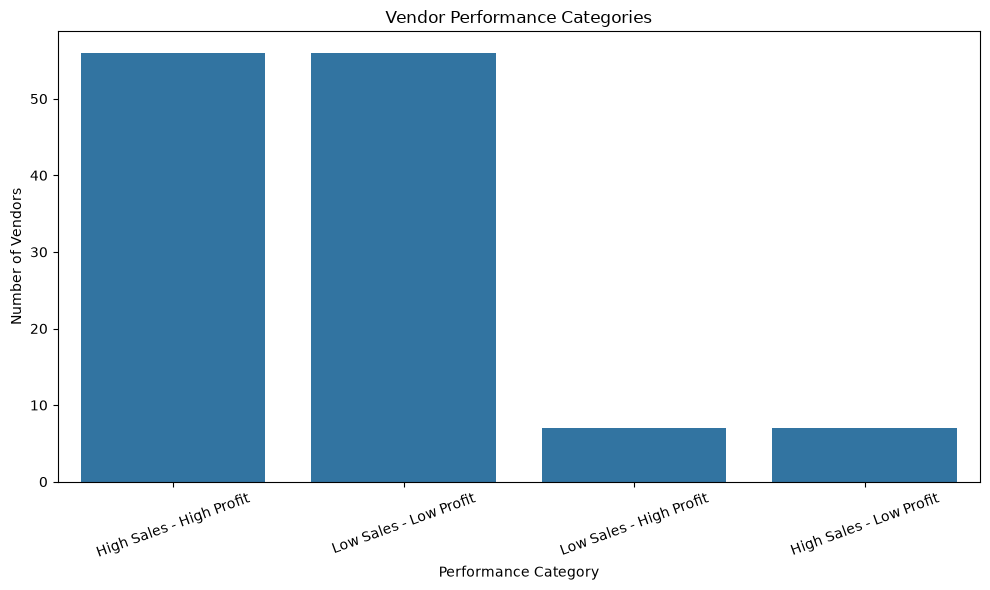

In [100]:
category_counts = (
    vendor_performance["PerformanceCategory"]
    .value_counts()
    .reset_index()
)

category_counts.columns = [
    "PerformanceCategory",
    "VendorCount"
]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_counts,
    x="PerformanceCategory",
    y="VendorCount"
)

plt.title("Vendor Performance Categories")
plt.xlabel("Performance Category")
plt.ylabel("Number of Vendors")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [101]:
final_file = os.path.join(
    folder,
    "vendor_performance_final.csv"
)

vendor_performance.to_csv(
    final_file,
    index=False
)

print("Final dataset saved:")
print(final_file)

Final dataset saved:
C:\Users\Harshit\project data\vendor_performance_final.csv


In [102]:
brand_file = os.path.join(
    folder,
    "brand_performance.csv"
)

brand_performance.to_csv(
    brand_file,
    index=False
)

print("Brand dataset saved:")
print(brand_file)

Brand dataset saved:
C:\Users\Harshit\project data\brand_performance.csv


In [103]:
print("Final vendor dataset:", vendor_performance.shape)

display(vendor_performance.head())

print("\nColumns:")
print(vendor_performance.columns.tolist())

Final vendor dataset: (126, 8)


,VendorNumber,TotalPurchases,TotalSales,GrossProfit,ProfitMargin,TotalFreight,FreightPercentage,PerformanceCategory
0,3960,50959796.85,68742416.99,17782620.14,25.87,257032.07,0.504382,High Sales - High Profit
1,4425,27861690.02,41047306.30,13185616.28,32.12,144929.24,0.520174,High Sales - High Profit
2,1392,15573917.90,24469172.93,8895255.03,36.35,79528.99,0.510655,High Sales - High Profit
3,17035,24124091.56,32281247.95,8157156.39,25.27,123780.22,0.513098,High Sales - High Profit
4,12546,24203151.05,31906320.54,7703169.49,24.14,123880.97,0.511838,High Sales - High Profit



Columns:
['VendorNumber', 'TotalPurchases', 'TotalSales', 'GrossProfit', 'ProfitMargin', 'TotalFreight', 'FreightPercentage', 'PerformanceCategory']


In [104]:
correlation_columns = [
    "TotalPurchases",
    "TotalSales",
    "TotalFreight",
    "GrossProfit",
    "ProfitMargin"
]

correlation_matrix = vendor_performance[
    correlation_columns
].corr()

display(correlation_matrix)

,TotalPurchases,TotalSales,TotalFreight,GrossProfit,ProfitMargin
TotalPurchases,1.000000,0.998600,0.999932,0.981978,0.062569
TotalSales,0.998600,1.000000,0.998784,0.990600,0.064521
TotalFreight,0.999932,0.998784,1.000000,0.982811,0.062680
GrossProfit,0.981978,0.990600,0.982811,1.000000,0.068727
ProfitMargin,0.062569,0.064521,0.062680,0.068727,1.000000


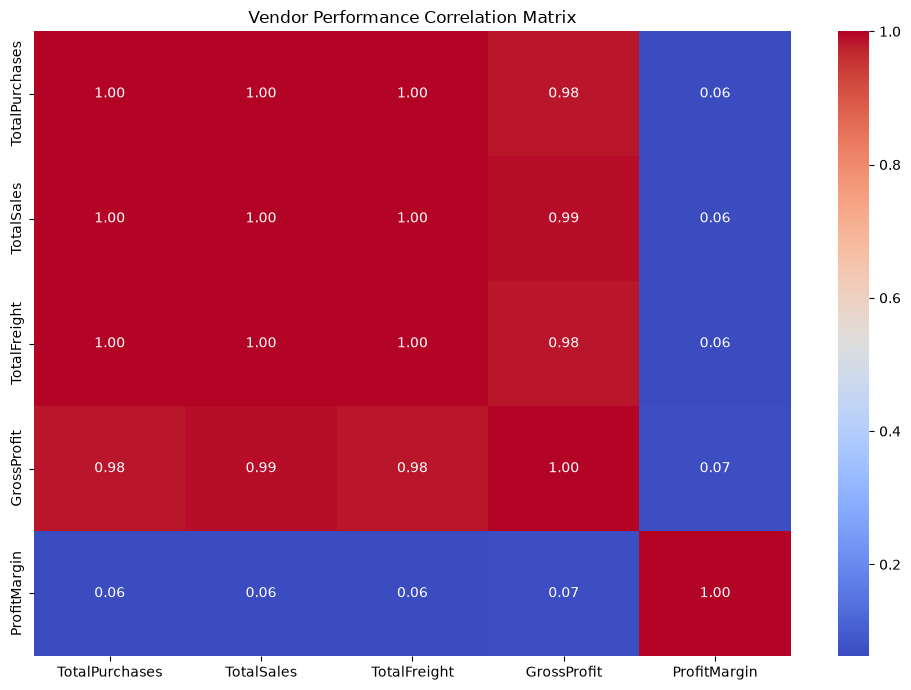

In [105]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Vendor Performance Correlation Matrix")
plt.tight_layout()
plt.show()

In [106]:
sales_median = vendor_performance["TotalSales"].median()
margin_median = vendor_performance["ProfitMargin"].median()

high_sales_low_margin = vendor_performance[
    (vendor_performance["TotalSales"] >= sales_median) &
    (vendor_performance["ProfitMargin"] < margin_median)
].sort_values(
    "TotalSales",
    ascending=False
)

display(high_sales_low_margin.head(15))

,VendorNumber,TotalPurchases,TotalSales,GrossProfit,ProfitMargin,TotalFreight,FreightPercentage,PerformanceCategory
0,3960,50959796.85,68742416.99,17782620.14,25.87,257032.07,0.504382,High Sales - High Profit
3,17035,24124091.56,32281247.95,8157156.39,25.27,123780.22,0.513098,High Sales - High Profit
4,12546,24203151.05,31906320.54,7703169.49,24.14,123880.97,0.511838,High Sales - High Profit
7,1128,13529433.08,18478557.47,4949124.39,26.78,68601.68,0.507055,High Sales - High Profit
8,9165,13210613.93,17822938.45,4612324.52,25.88,68054.70,0.515152,High Sales - High Profit
11,8004,9916770.26,13250928.19,3334157.93,25.16,50293.62,0.507157,High Sales - High Profit
19,3664,5960744.35,7635828.27,1675083.92,21.94,30234.42,0.507226,High Sales - High Profit
21,11567,4141720.71,5610527.44,1468806.73,26.18,20964.81,0.506186,High Sales - High Profit
28,8664,3666478.72,4663847.60,997368.88,21.39,18544.49,0.505785,High Sales - High Profit
29,7239,3354958.28,4294875.05,939916.77,21.88,16978.67,0.506077,High Sales - High Profit


In [107]:
vendor_ranked = vendor_performance.sort_values(
    "TotalSales",
    ascending=False
).copy()

vendor_ranked["SalesPercentage"] = (
    vendor_ranked["TotalSales"]
    / vendor_ranked["TotalSales"].sum()
) * 100

vendor_ranked["CumulativeSalesPercentage"] = (
    vendor_ranked["SalesPercentage"].cumsum()
)

display(
    vendor_ranked[
        [
            "VendorNumber",
            "TotalSales",
            "SalesPercentage",
            "CumulativeSalesPercentage"
        ]
    ].head(20)
)

,VendorNumber,TotalSales,SalesPercentage,CumulativeSalesPercentage
0,3960,68742416.99,15.206385,15.206385
1,4425,41047306.30,9.080000,24.286385
3,17035,32281247.95,7.140876,31.427261
4,12546,31906320.54,7.057939,38.485200
5,480,25014556.89,5.533425,44.018625
2,1392,24469172.93,5.412781,49.431406
6,3252,18556085.61,4.104758,53.536164
7,1128,18478557.47,4.087608,57.623772
8,9165,17822938.45,3.942580,61.566352
9,9552,15465247.75,3.421039,64.987391


In [108]:
top10_contribution = (
    vendor_ranked.head(10)["TotalSales"].sum()
    / vendor_ranked["TotalSales"].sum()
) * 100

print(
    f"Top 10 vendors contribute "
    f"{top10_contribution:.2f}% of total sales."
)

Top 10 vendors contribute 64.99% of total sales.


In [109]:
sales_median = vendor_performance["TotalSales"].median()
profit_median = vendor_performance["GrossProfit"].median()

def classify_vendor(row):
    if row["TotalSales"] >= sales_median and row["GrossProfit"] >= profit_median:
        return "High Sales - High Profit"
    elif row["TotalSales"] >= sales_median and row["GrossProfit"] < profit_median:
        return "High Sales - Low Profit"
    elif row["TotalSales"] < sales_median and row["GrossProfit"] >= profit_median:
        return "Low Sales - High Profit"
    else:
        return "Low Sales - Low Profit"

vendor_performance["PerformanceCategory"] = (
    vendor_performance.apply(classify_vendor, axis=1)
)

display(
    vendor_performance[
        [
            "VendorNumber",
            "TotalSales",
            "GrossProfit",
            "ProfitMargin",
            "PerformanceCategory"
        ]
    ].head(15)
)

,VendorNumber,TotalSales,GrossProfit,ProfitMargin,PerformanceCategory
0,3960,68742416.99,17782620.14,25.87,High Sales - High Profit
1,4425,41047306.30,13185616.28,32.12,High Sales - High Profit
2,1392,24469172.93,8895255.03,36.35,High Sales - High Profit
3,17035,32281247.95,8157156.39,25.27,High Sales - High Profit
4,12546,31906320.54,7703169.49,24.14,High Sales - High Profit
5,480,25014556.89,7390178.17,29.54,High Sales - High Profit
6,3252,18556085.61,6266477.52,33.77,High Sales - High Profit
7,1128,18478557.47,4949124.39,26.78,High Sales - High Profit
8,9165,17822938.45,4612324.52,25.88,High Sales - High Profit
9,9552,15465247.75,4529430.45,29.29,High Sales - High Profit


In [110]:
final_file = os.path.join(
    folder,
    "vendor_performance_final.csv"
)

vendor_performance.to_csv(
    final_file,
    index=False
)

print("Final dataset saved:")
print(final_file)

Final dataset saved:
C:\Users\Harshit\project data\vendor_performance_final.csv


In [111]:
import os

print(os.path.exists(
    r"C:\Users\Harshit\project data\vendor_performance_final.csv"
))

True
